In [1]:
from lib.ACE.ace_data_loading import *
from lib.ACE.ace_plotting import *
from lib.ACE.ace_analysis import * 
from lib.ACI.aci_data_loading import *
from lib.ACI.aci_plotting import * 
from lib.general.ead_file_loading import *
from lib.general.colorbars import get_continuous_cmap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.gridspec import GridSpec
from matplotlib.colors import BoundaryNorm, ListedColormap
import os 
import colorcet as cc 

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.sans-serif'] = ['Luminari']
plt.rcParams['font.size']=10
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['mathtext.rm'] = 'Luminari'

ImportError: attempted relative import beyond top-level package

In [4]:
t0 = '2025-10-07/07:30:00'
tf = '2025-10-07/07:38:10'

ead = EADload(t0,tf,'2')
ead_data = ead.read_data(params=['lat_geo','lon_geo','lat_geod','lon_geod','alt_geod','mlat','mlt','r_sm'])
l2 = ACE_L2(t0,tf,'2')
l2_data = l2.read_data()
l3 = ACE_L3(t0,tf,'2')
l3_data = l3.read_data()

mlt_interp_f = interp1d(ead_data['UTC'], ead_data['ts2_ead_mlt'], kind='linear')
mlat_interp_f = interp1d(ead_data['UTC'], ead_data['ts2_ead_mlat'], kind='linear')
interp_mlt = mlt_interp_f(l2_data['UTC'])
interp_mlat = mlat_interp_f(l2_data['UTC'])

l2_copy = l2_data.copy()
invertedVs = pd.read_csv('oct7_invertedV_times.csv',header=0)
n_events = len(invertedVs['Event'])
max_energies = np.zeros(n_events)
mean_energies = np.zeros(n_events)
std_energies = np.zeros(n_events)

mlt_start = np.zeros(n_events)
mlt_end = np.zeros(n_events)
mlat_start = np.zeros(n_events)
mlat_end = np.zeros(n_events)


for k in range(11):
    t0 = '2025-10-07/'+invertedVs['Start'].iloc[k]
    tf = '2025-10-07/'+invertedVs['End'].iloc[k]
    t_e, c_e = get_characteristic_energies(l2_copy, trange=[t0,tf], return_times=True)
    max_energies[k] = np.nanmax(c_e)
    mean_energies[k] = np.nanmean(c_e)
    std_energies[k] = np.nanstd(c_e)


step_x = [[0], invertedVs['Event'][0:11], [12]]
step_y = [[0], max_energies[0:11], [12]]
xx = [x for xs in step_x for x in xs]
yy = [y for ys in step_y for y in ys]



C:\Users\shndrsn\TRACERS_data_routines/data/TS2/EAD/2025/10/ts2_def_ead_20251007_v0.10.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


In [5]:
mean_energies

array([3636.34162215,  882.22993971, 1103.81822548, 1340.2404946 ,
       1409.20478596, 3470.5048805 , 1677.46248115, 2666.48735248,
       1303.60237191, 1515.95783289, 1311.60743094,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ])

In [63]:
ts = '2025-11-12/04:18'
te = '2025-11-12/04:25'

l2 = ACE_L2(ts,te,'2')
l2_data = l2.read_data()
l3 = ACE_L3(ts,te,'2')
l3_data = l3.read_data()

l2_aci = ACI_L2(ts,te,'2')
aci = l2_aci.read_data()

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/11/ts2_l2_ace_def_20251112_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/11/ts2_l3_ace_pitch-angle-dist_20251112_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACI/l2/2025/11/ts2_l2_aci_ipd_20251112_v1.0.0.cdf


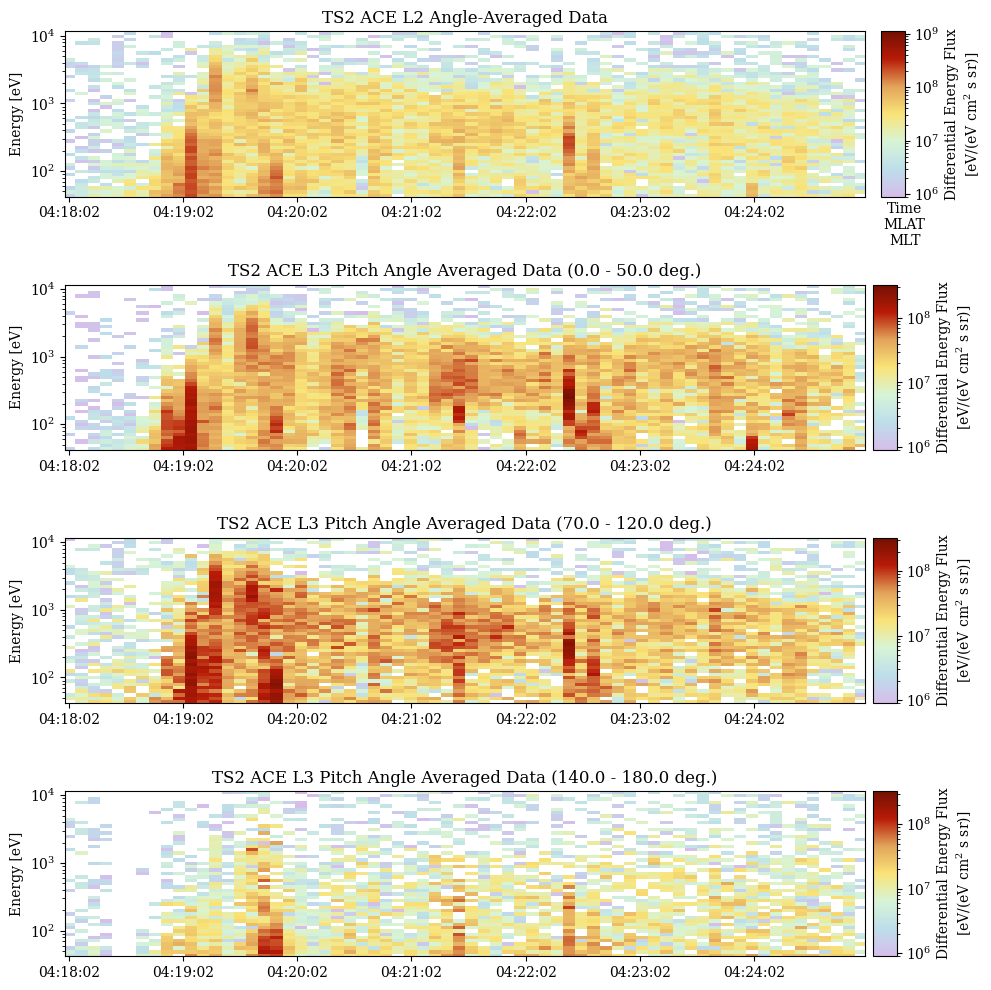

In [67]:
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(411)
ax2 = fig.add_subplot(412,sharex=ax1)
ax3 = fig.add_subplot(413,sharex=ax1)
ax4 = fig.add_subplot(414,sharex=ax1)

hex_list = ['#D7BEEB','#BEDFEB','#D8F5D7','#FAE478','#E3A45B','#B81B07','#731003']
my_cmap=get_continuous_cmap(hex_list)

ax1 = plot_ace_l2(l2_data,ax=ax1,time_res='1min',spice=True,cmap=my_cmap,zlim=[1e6,1e9])
ax2 = plot_ace_l3(l3_data,ax=ax2,time_res='1min',pa_bins2avg=[0,1,2,3,4],cmap=my_cmap,zlim=[1e6,3e8])
ax3 = plot_ace_l3(l3_data,ax=ax3,time_res='1min',pa_bins2avg=[7,8,9,10,11], cmap=my_cmap,zlim=[1e6,3e8])
ax4 = plot_ace_l3(l3_data,ax=ax4,time_res='1min',pa_bins2avg=[14,15,16,17],cmap=my_cmap,zlim=[1e6,3e8])
plt.tight_layout()
plt.savefig('pitch_angles_20251112_0423.png')
plt.show()
plt.close()

In [51]:
ts = '2025-11-12/03:30'
te = '2025-11-12/05:00'

l2 = ACE_L2(ts,te,'2')
l2_data = l2.read_data()
l3 = ACE_L3(ts,te,'2')
l3_data = l3.read_data()

l2_aci = ACI_L2(ts,te,'2')
aci = l2_aci.read_data()

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/11/ts2_l2_ace_def_20251112_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/11/ts2_l3_ace_pitch-angle-dist_20251112_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACI/l2/2025/11/ts2_l2_aci_ipd_20251112_v1.0.0.cdf


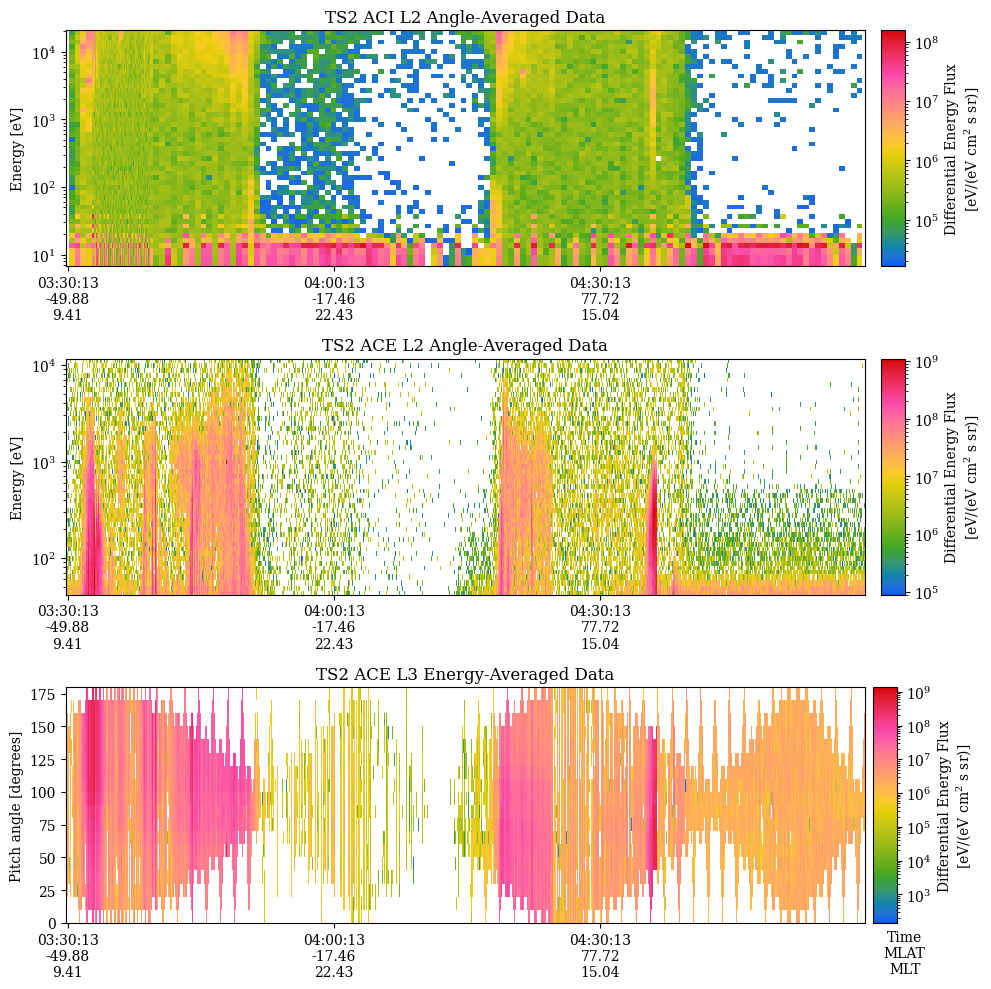

In [55]:
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(311)
ax2 = fig.add_subplot(312,sharex=ax1)
ax3 = fig.add_subplot(313,sharex=ax1)

cmap = plt.get_cmap('cet_CET_R3')

ax1 = plot_aci_l2(aci,ax=ax1,cmap=cmap)
ax2 = plot_ace_l2(l2_data,ax=ax2,cmap=cmap,zlim=[1e5,1e9])
ax3 = plot_ace_l3(l3_data,ax=ax3,spice=True,cmap=cmap,time_res='30min')
plt.tight_layout()
#plt.savefig('TS2_20251112_0431.png')
plt.show()

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/11/ts2_l2_ace_def_20251112_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/11/ts2_l3_ace_pitch-angle-dist_20251112_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACI/l2/2025/11/ts2_l2_aci_ipd_20251112_v1.0.0.cdf


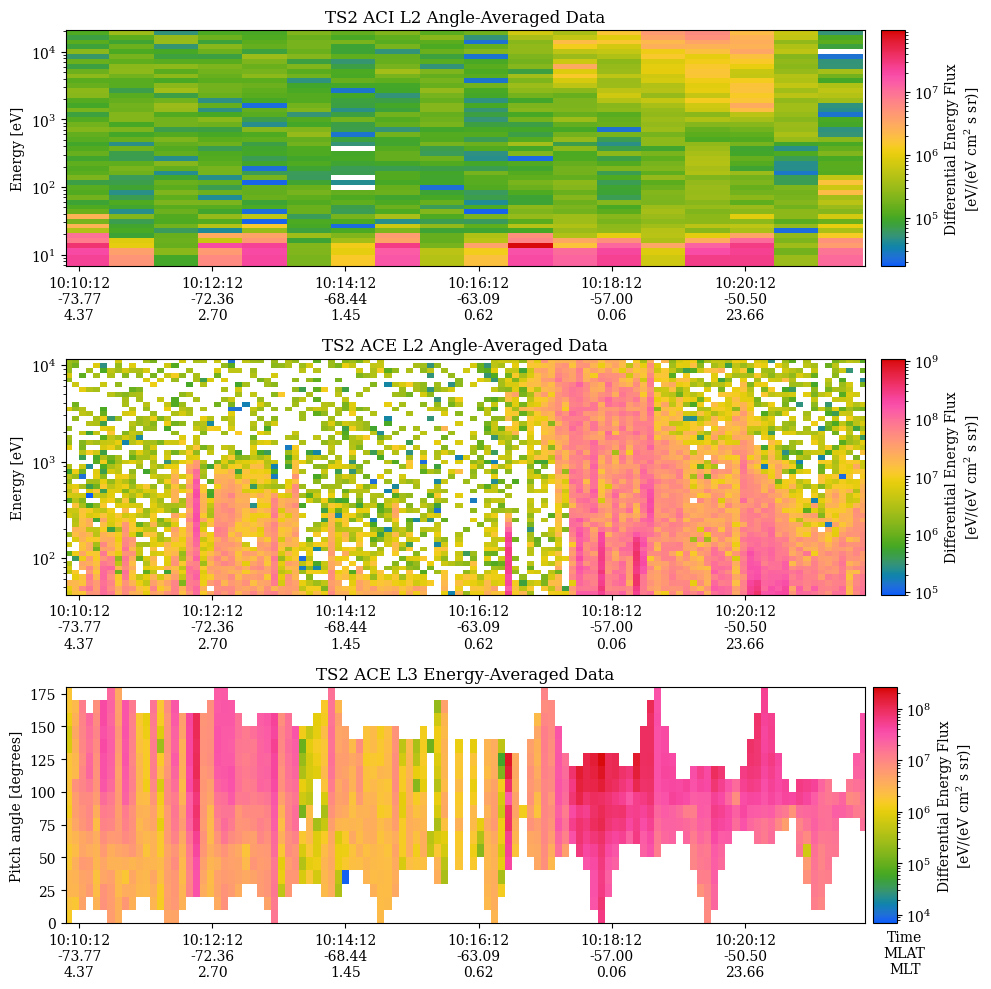

In [23]:
ts = '2025-11-12/10:10'
te = '2025-11-12/10:22'

l2 = ACE_L2(ts,te,'2')
l2_data = l2.read_data()
l3 = ACE_L3(ts,te,'2')
l3_data = l3.read_data()

l2_aci = ACI_L2(ts,te,'2')
aci = l2_aci.read_data()

fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(311)
ax2 = fig.add_subplot(312,sharex=ax1)
ax3 = fig.add_subplot(313,sharex=ax1)

cmap = plt.get_cmap('cet_CET_R3')

ax1 = plot_aci_l2(aci,ax=ax1,time_res='2min',cmap=cmap)
ax2 = plot_ace_l2(l2_data,ax=ax2,time_res='2min',cmap=cmap,zlim=[1e5,1e9])
ax3 = plot_ace_l3(l3_data,ax=ax3,time_res='2min',spice=True,cmap=cmap)
plt.tight_layout()
plt.savefig('TS2_20251112_1016.png')
plt.show()



In [48]:
fname = 'C:/Users/shndrsn/TRACERS_data_routines/data/TS2/EAD/2025/10/ts2_def_ead_20251007_v0.10.0.cdf'
mod_date = os.path.getmtime(fname)
dt.datetime.fromtimestamp(mod_date, dt.timezone.utc)

datetime.datetime(2026, 2, 9, 19, 32, 15, 408698, tzinfo=datetime.timezone.utc)

In [13]:
t0 = '2025-10-07/07:38:10'
tf = '2025-10-07/07:39:37'

ead = EADload(t0,tf,'2')
ead_data = ead.read_data(params=['lat_geo','lon_geo','lat_geod','lon_geod','alt_geod','mlat','mlt','r_sm'])
l2 = ACE_L2(t0,tf,'2')
l2_data = l2.read_data()
l3 = ACE_L3(t0,tf,'2')
l3_data = l3.read_data()


fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(311)
ax2 = fig.add_subplot(312,sharex=ax1)
ax3 = fig.add_subplot(313,sharex=ax1)

cmap = plt.get_cmap('cet_CET_R3')

ax1 = plot_aci_l2(aci,ax=ax1,time_res='2min',cmap=cmap)
ax2 = plot_ace_l2(l2_data,ax=ax2,time_res='2min',cmap=cmap,zlim=[1e5,1e9])
ax3 = plot_ace_l3(l3_data,ax=ax3,time_res='2min',spice=True,cmap=cmap)
plt.tight_layout()
plt.savefig('TS2_20251112_0431.png')
plt.show()

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/EAD/2025/10/ts2_def_ead_20251007_v0.10.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


In [57]:
# 0 = nominal inverted V, 1 = hybrid
event_categories = np.array([0,0,0,1,0,1,1,0,1,1,1,1,1,1,0,0])
invertedVs = pd.read_csv('oct7_invertedV_times.csv',header=0)
cuspVs = invertedVs.iloc[11:]
auroralVs = invertedVs.iloc[0:11]

In [54]:
total_durations = np.zeros(16)
for k in range(len(cuspVs['Start'])):
    t0 = '2025-10-07/'+cuspVs['Start'].iloc[k]
    tf = '2025-10-07/'+cuspVs['End'].iloc[k]
    delta_t = (dt.datetime.strptime(tf,'%Y-%m-%d/%H:%M:%S.%f') - dt.datetime.strptime(t0,'%Y-%m-%d/%H:%M:%S.%f'))/2.
    total_durations[k] = delta_t.total_seconds()
print(np.mean(total_durations))
print(np.std(total_durations))
print(np.amin(total_durations))
print(np.amax(total_durations))

0.9559375000000001
0.7695315513958801
0.36
3.41


In [55]:
total_durations_a = np.zeros(11)
for k in range(len(auroralVs['Start'])):
    t0 = '2025-10-07/'+auroralVs['Start'].iloc[k]
    tf = '2025-10-07/'+auroralVs['End'].iloc[k]
    delta_t = (dt.datetime.strptime(tf,'%Y-%m-%d/%H:%M:%S.%f') - dt.datetime.strptime(t0,'%Y-%m-%d/%H:%M:%S.%f'))/2.
    total_durations_a[k] = delta_t.total_seconds()
print(np.mean(total_durations_a))
print(np.std(total_durations_a))
print(np.min(total_durations_a))
print(np.max(total_durations_a))

17.243590909090905
14.208798613436326
3.195
50.93


In [15]:
delta_lambda = [0.24364021, 0.10951873, 0.05819277, 0.07252831, 0.16738617,\
                0.05345291, 0.03936518, 0.04729162, 0.03060933, 0.06914339,\
                0.03210845, 0.0348006, 0.08190057, 0.04114034, 0.09618129, 0.05461156]

In [56]:
print(np.mean(delta_lambda))
print(np.std(delta_lambda))

0.076991964375
0.05500692178062753


In [16]:
mid_times = []
for k in range(len(cuspVs['Start'])):
    t0 = '2025-10-07/'+cuspVs['Start'].iloc[k]
    tf = '2025-10-07/'+cuspVs['End'].iloc[k]

    delta_t = (dt.datetime.strptime(tf,'%Y-%m-%d/%H:%M:%S.%f') - dt.datetime.strptime(t0,'%Y-%m-%d/%H:%M:%S.%f'))/2.
    mid_time = dt.datetime.strptime(t0,'%Y-%m-%d/%H:%M:%S.%f') + delta_t
    mid_times.append(mid_time)

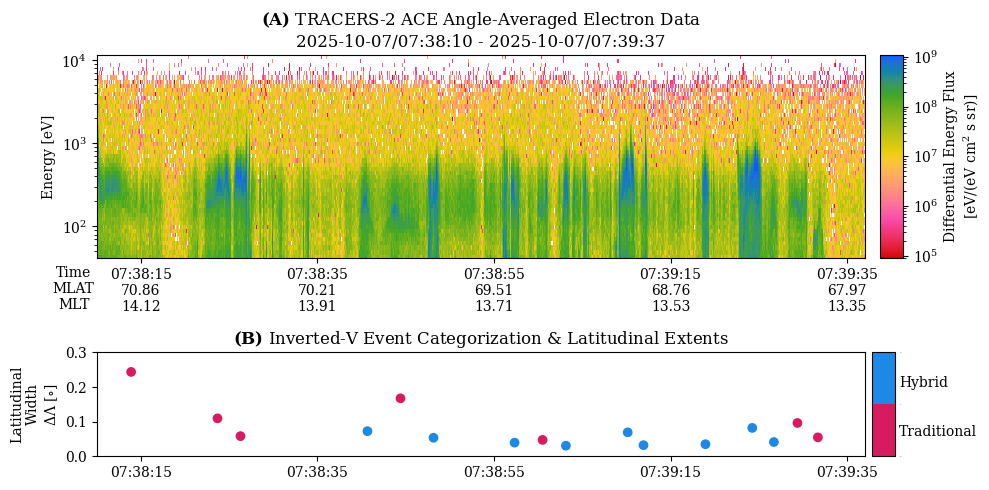

In [17]:
fig = plt.figure(figsize=(10,5))
gd = GridSpec(nrows=5,ncols=1)
ax1 = fig.add_subplot(gd[0:3])
t0 = '2025-10-07/07:38:10'
tf = '2025-10-07/07:39:37'
ax1 = plot_ace_l2(l2_data,ax=ax1,zlim=[1e5,1e9],title=r'$\mathbf{(A)}$'+' TRACERS-2 ACE Angle-Averaged Electron Data\n'+f'{t0} - {tf}')

tick_start = dt.datetime.strftime(l2_data['DT'][0] + dt.timedelta(seconds=5),'%Y-%m-%d/%H:%M:%S')
tick_end = dt.datetime.strftime(l2_data['DT'][-1],'%Y-%m-%d/%H:%M:%S')
new_tick_locations = pd.to_datetime(pd.date_range(start=tick_start,end=tick_end,freq='20s'))
new_ticks_utc = [(x - dt.datetime(1970,1,1)).total_seconds() for x in new_tick_locations]

mlt_interp_f = interp1d(ead_data['UTC'], ead_data['ts2_ead_mlt'], kind='linear')
mlat_interp_f = interp1d(ead_data['UTC'], ead_data['ts2_ead_mlat'], kind='linear')
interp_mlt = mlt_interp_f(new_ticks_utc)
interp_mlat = mlat_interp_f(new_ticks_utc)
ax1.set_xticks(new_tick_locations)

mlt0 = mlt_interp_f(new_ticks_utc)
mlat0 = mlat_interp_f(new_ticks_utc)

c0_ticks = []
c0_times = []
for k in range(len(mlt0)):
    tick_string = dt.datetime.strftime(new_tick_locations[k],'%H:%M:%S')
    mlt0_str = f'{mlt0[k]:.2f}'
    mlat0_str = f'{mlat0[k]:.2f}'
    c0_ticks.append(tick_string + '\n' + mlat0_str + '\n' + mlt0_str)
    c0_times.append(tick_string)
ax1.set_xticklabels(c0_ticks)
ax1.set_xlabel('Time\nMLAT\nMLT')
ax1.xaxis.set_label_coords(-0.03,-0.04)    

xlim = ax1.get_xlim()

binary_cmap = ListedColormap(['#D81B60', '#1E88E5'])
bounds = [0, 1.5, 3]

# 3. Create a normalization object that maps data values to the colors in the colormap
norm = BoundaryNorm(bounds, binary_cmap.N)

ax3 = fig.add_subplot(gd[3:])
im = ax3.scatter(mid_times, delta_lambda, c=event_categories, cmap=binary_cmap, norm=norm)
ax3.set_ylim([0,0.3])
ax3.set_ylabel('Latitudinal\nWidth\n'+r'$\Delta \Lambda \ [\circ]$')
ax3.set_title(r'$\mathbf{(B)}$'+' Inverted-V Event Categorization & Latitudinal Extents')
ax3.set_xlim([xlim[0],xlim[1]])
ax3.set_xticks(new_tick_locations)
ax3.set_xticklabels(c0_times)

cbax = ax3.inset_axes([1.01,0,0.03,1],transform=ax3.transAxes)
cb = plt.colorbar(im, cax=cbax)
cb.ax.tick_params(size=0,labelsize=0)

#cb.set_label('Hybrid\n\nTraditional',rotation=45, labelpad=20)
cbax.text(1.15,0.6,'Hybrid\n\n\nTraditional')

plt.tight_layout()
plt.savefig('invertedV_cusp.png',dpi=300)
plt.show()
plt.close()

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


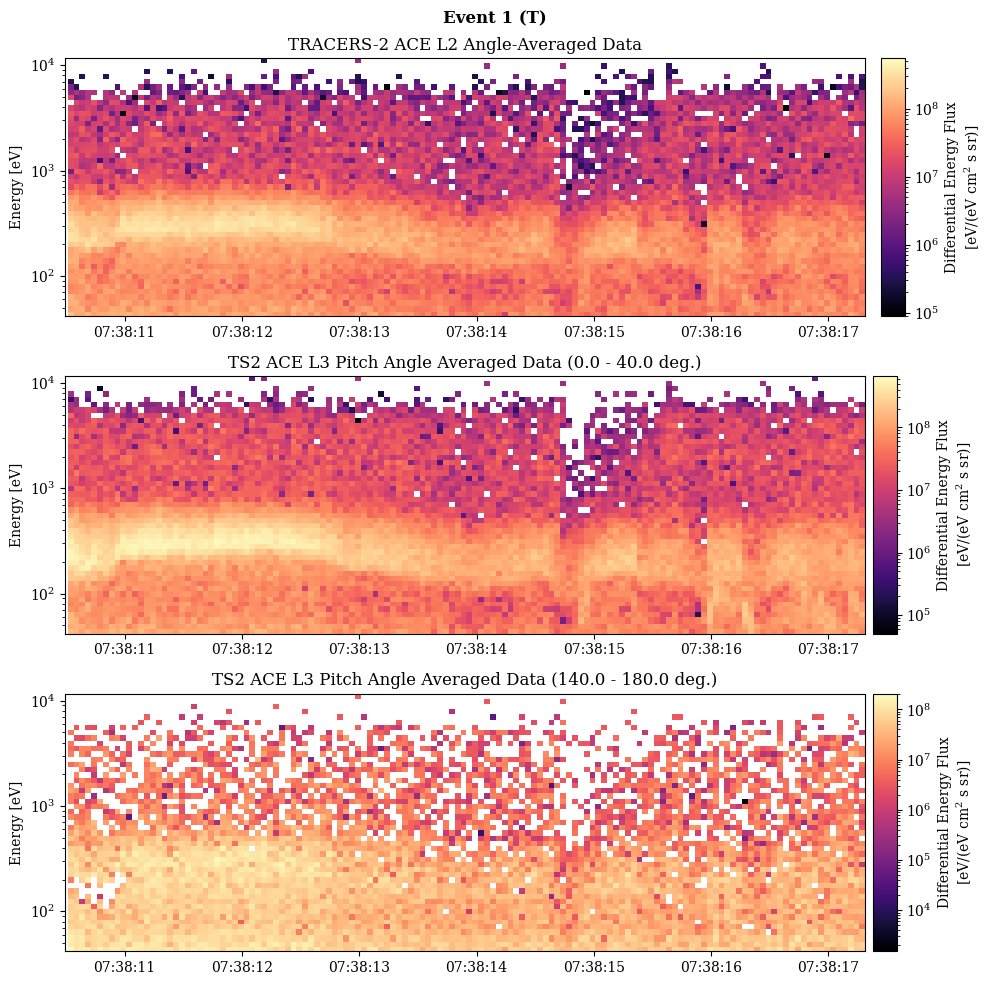

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


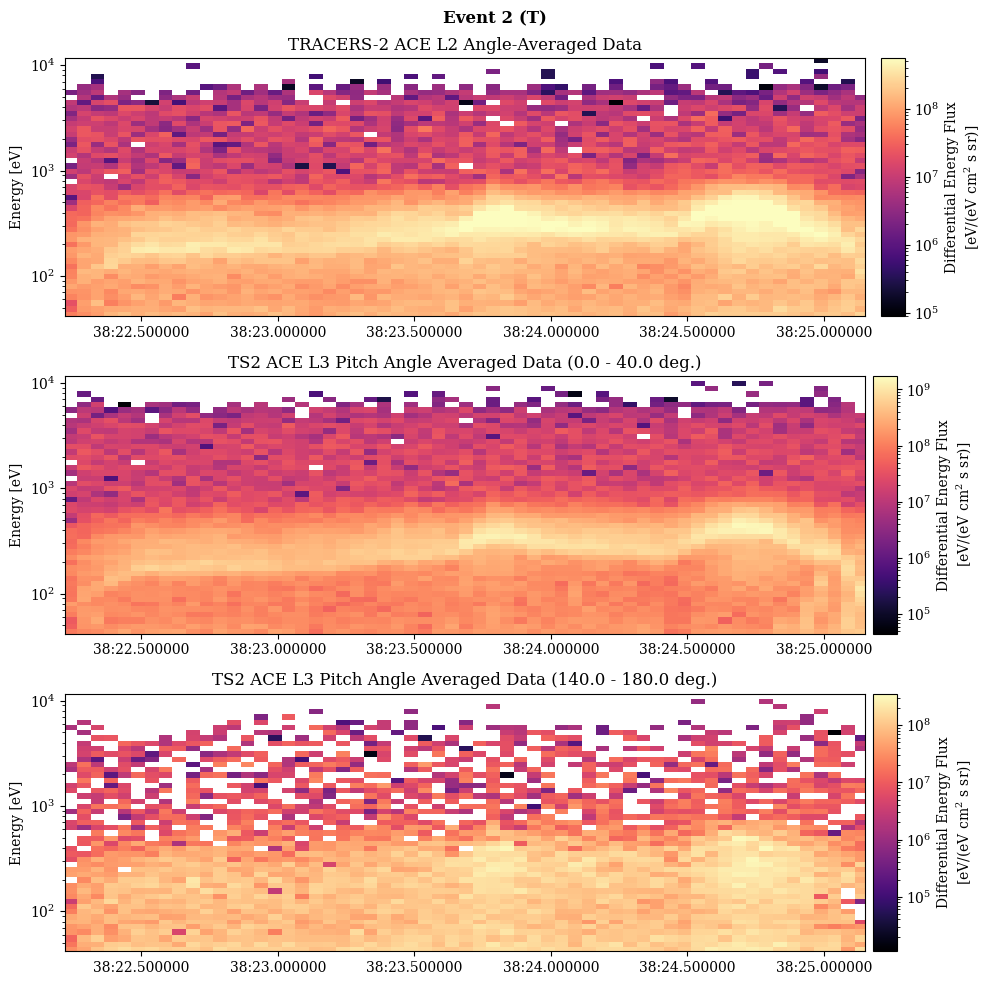

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


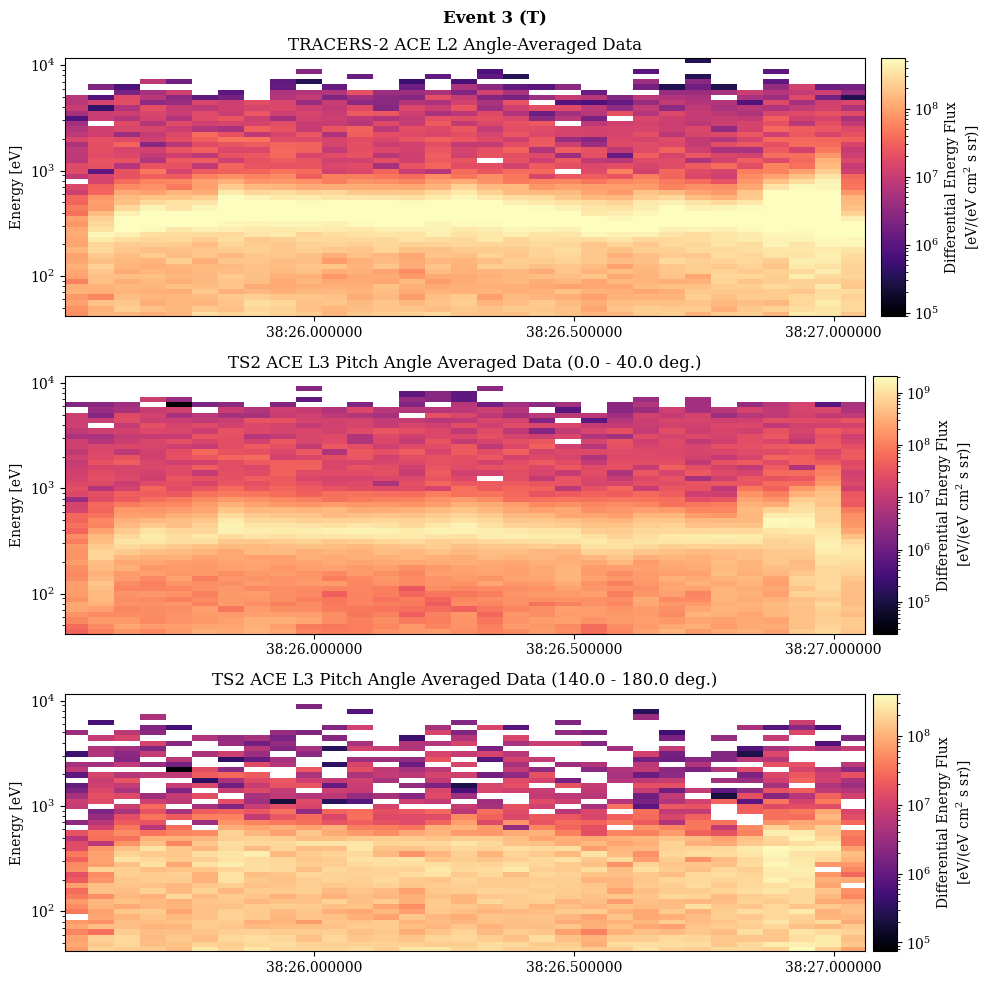

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


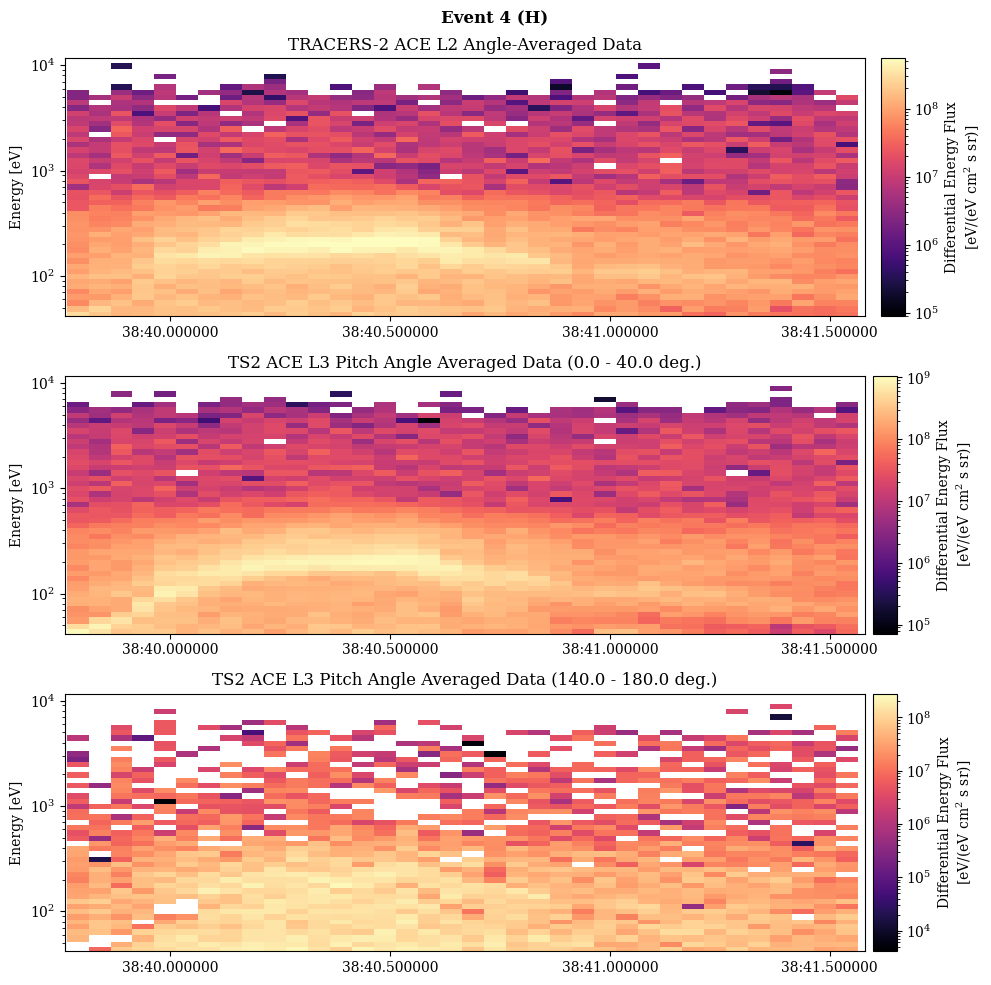

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


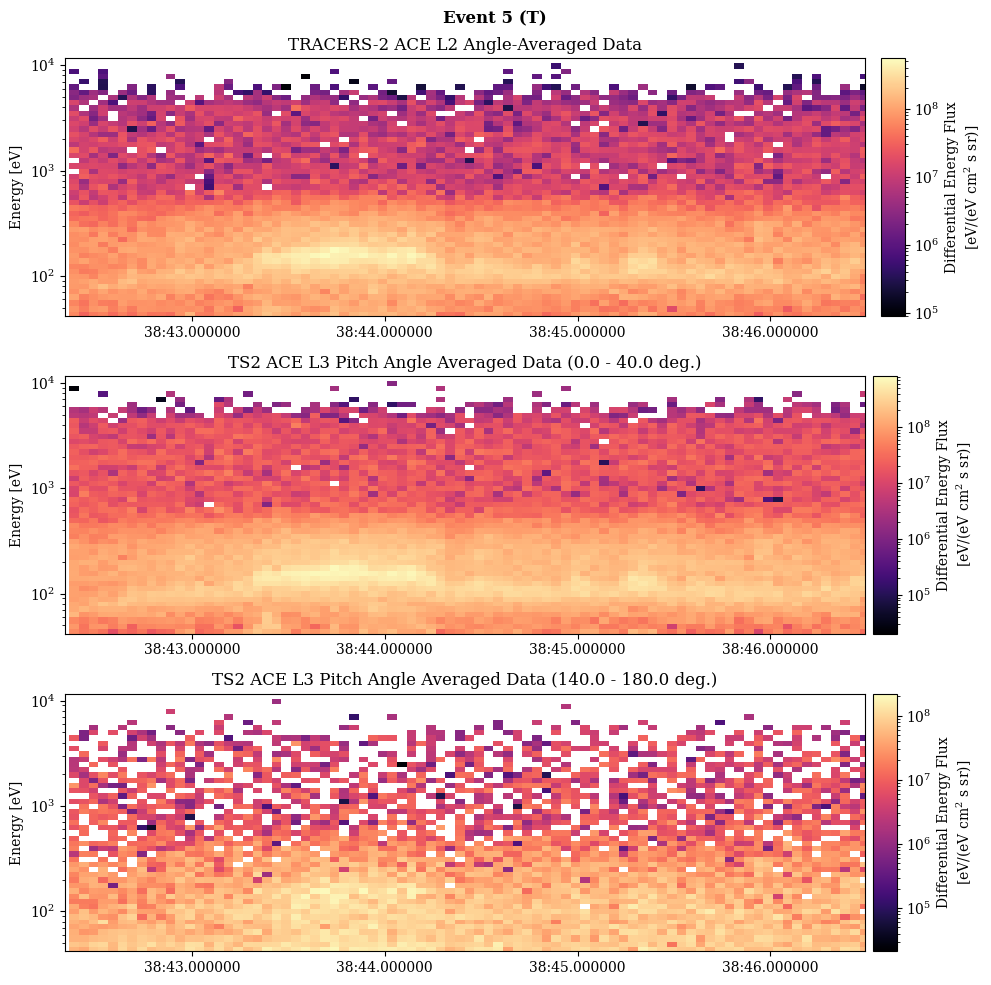

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


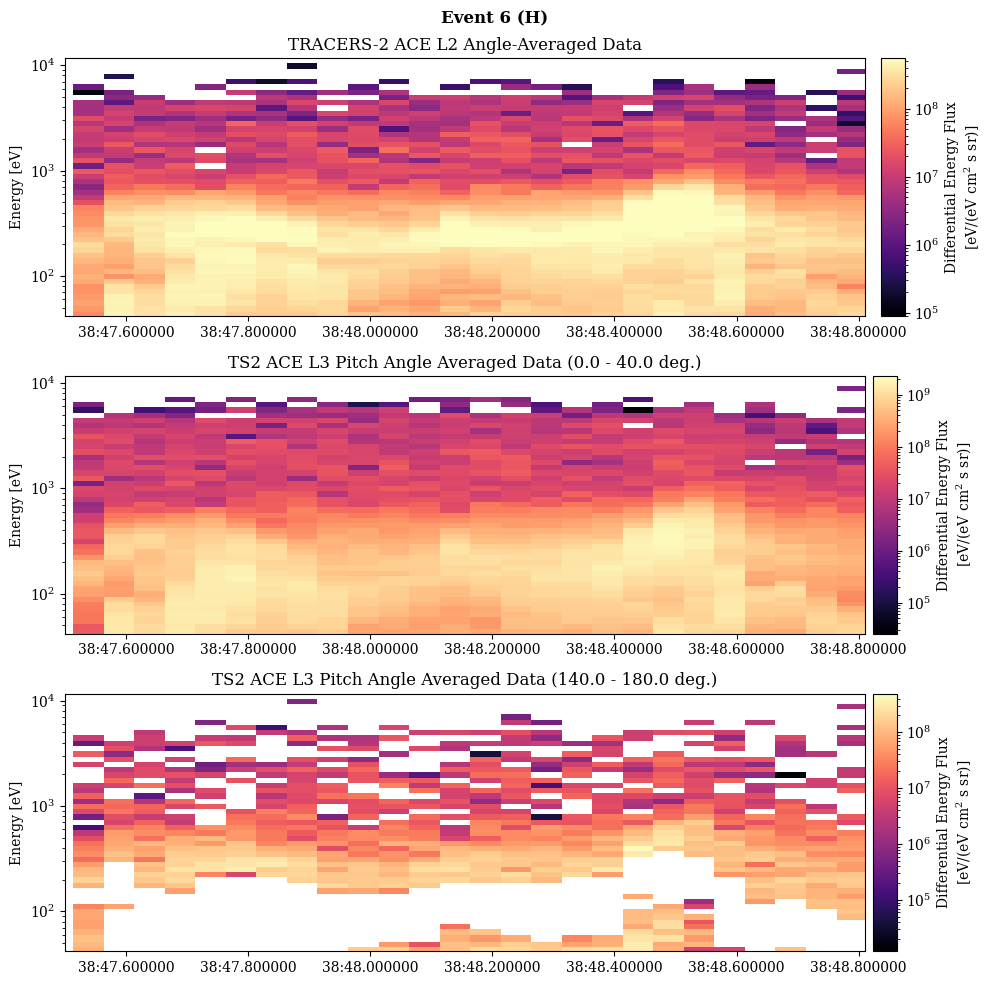

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


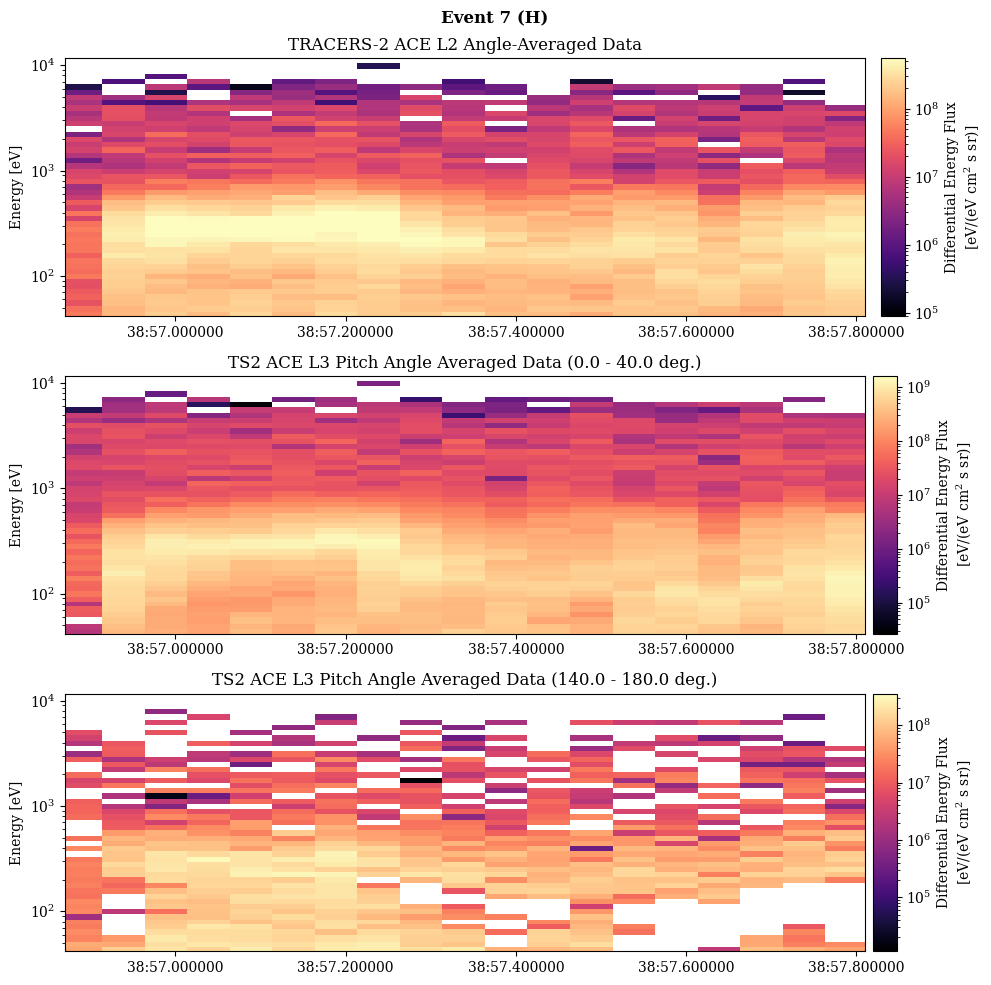

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


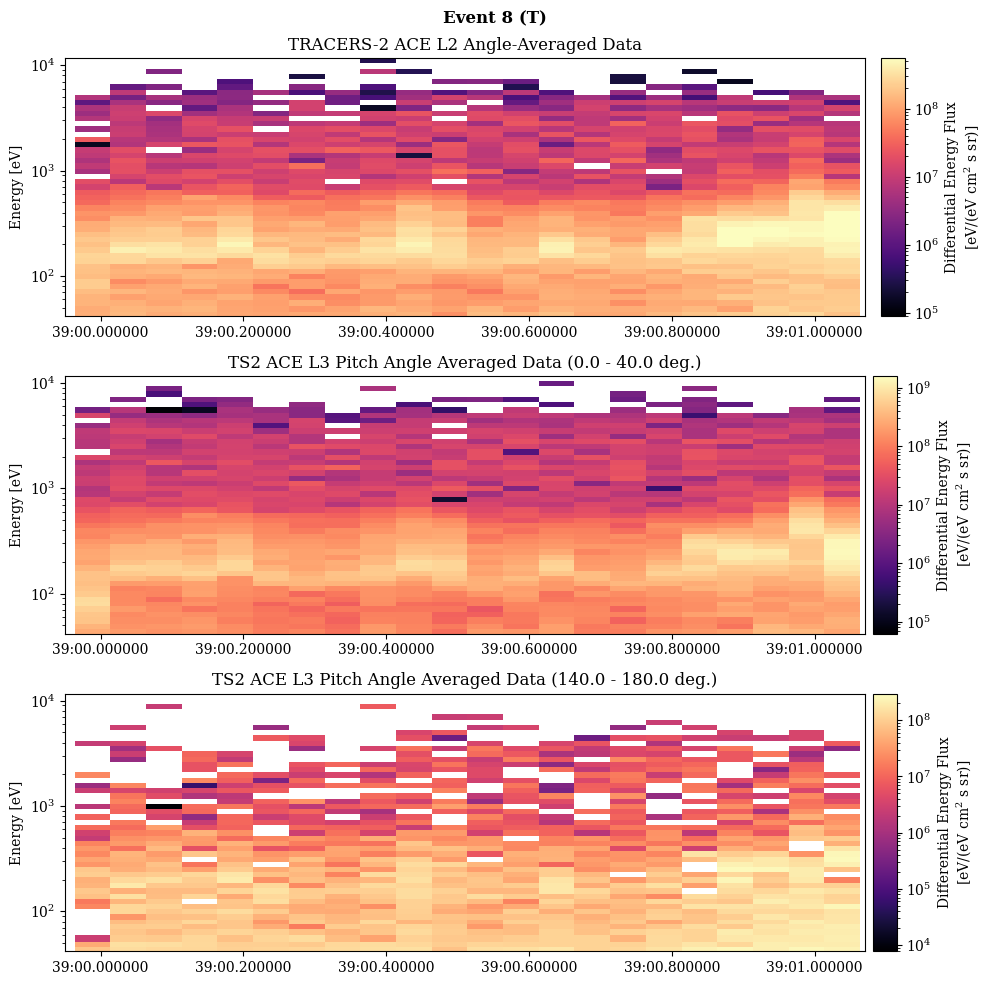

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


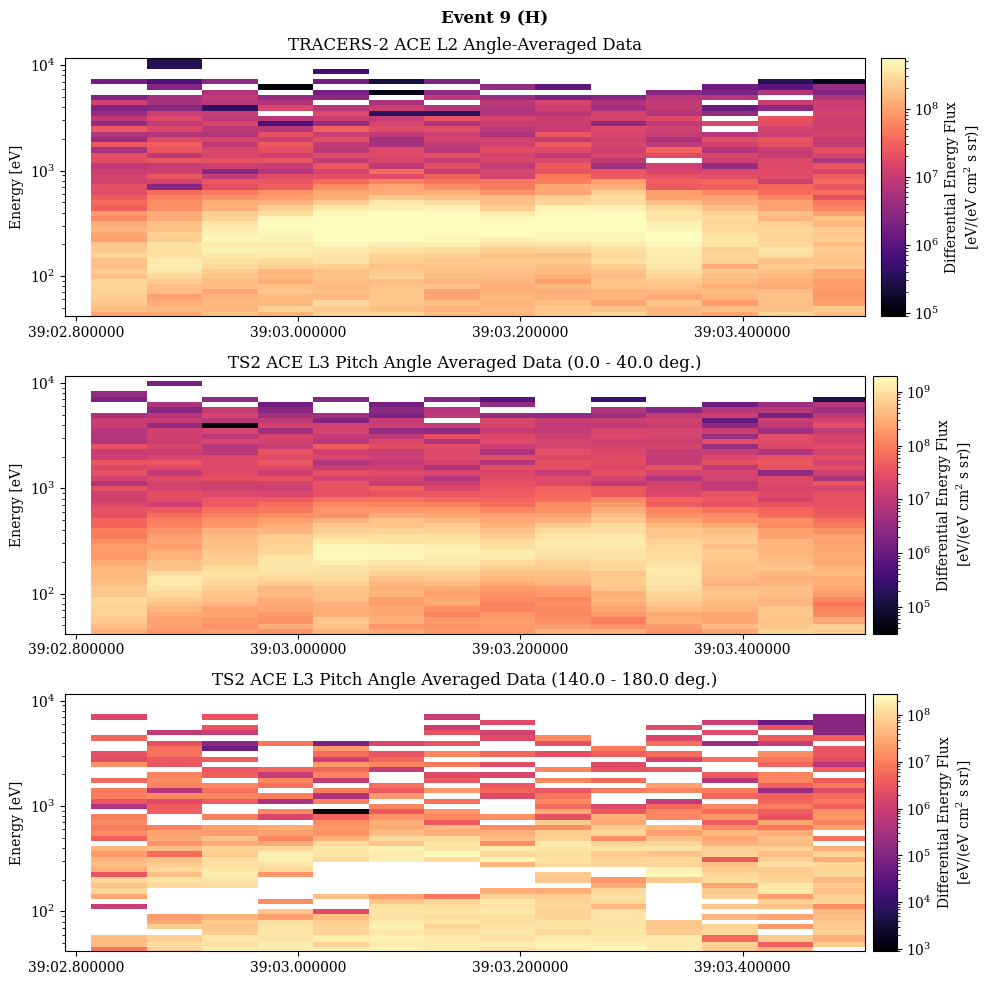

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


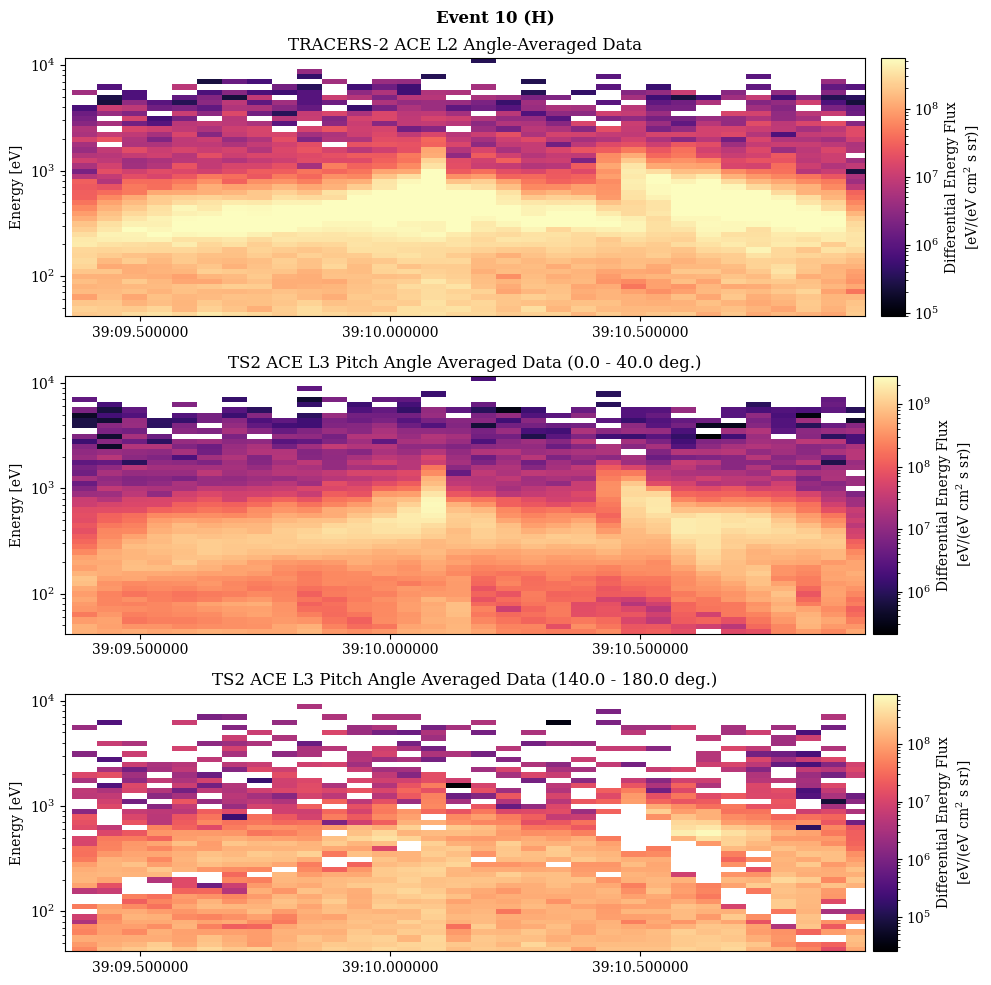

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


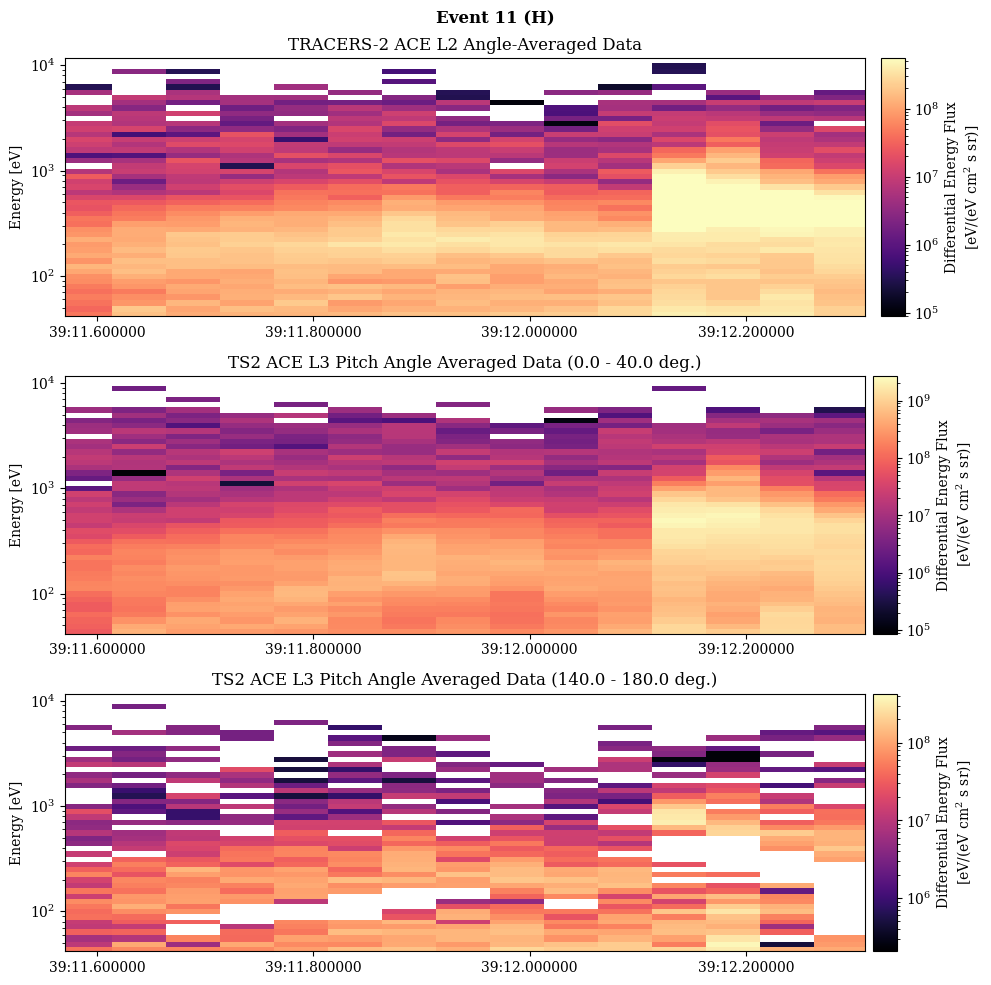

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


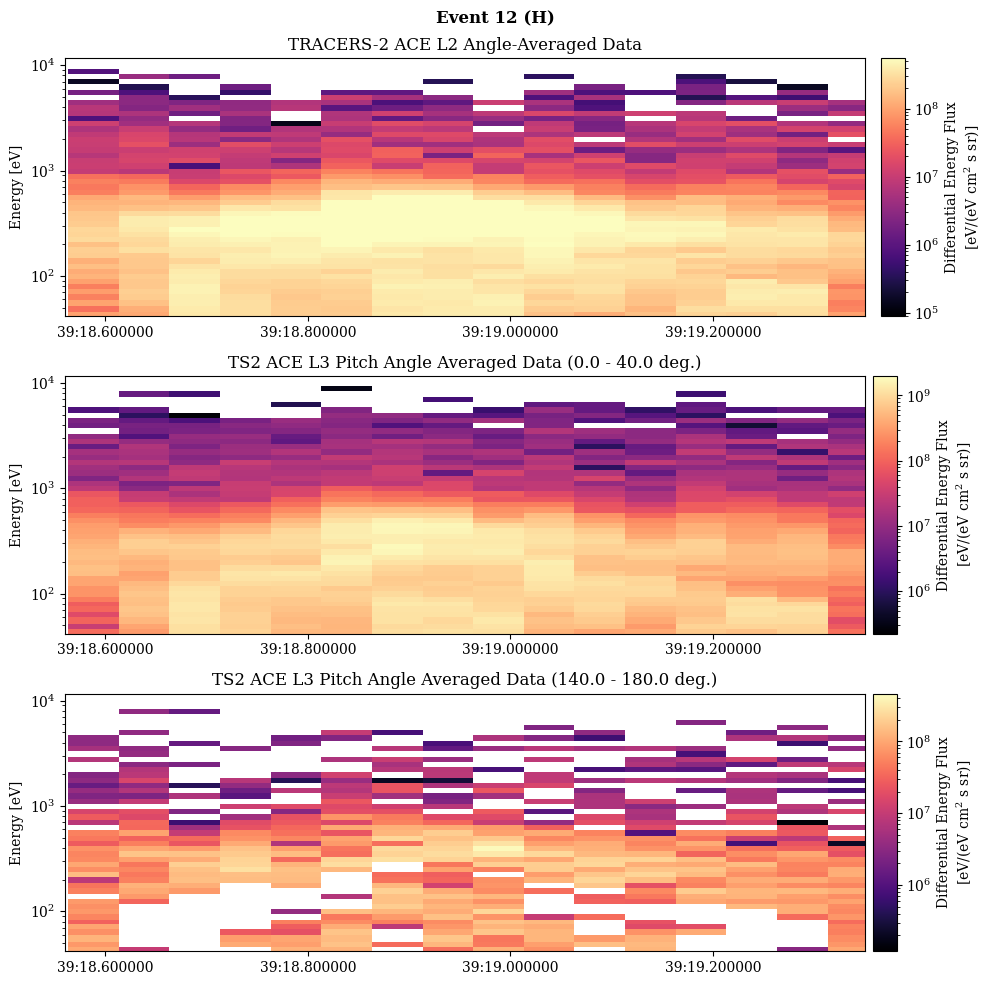

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


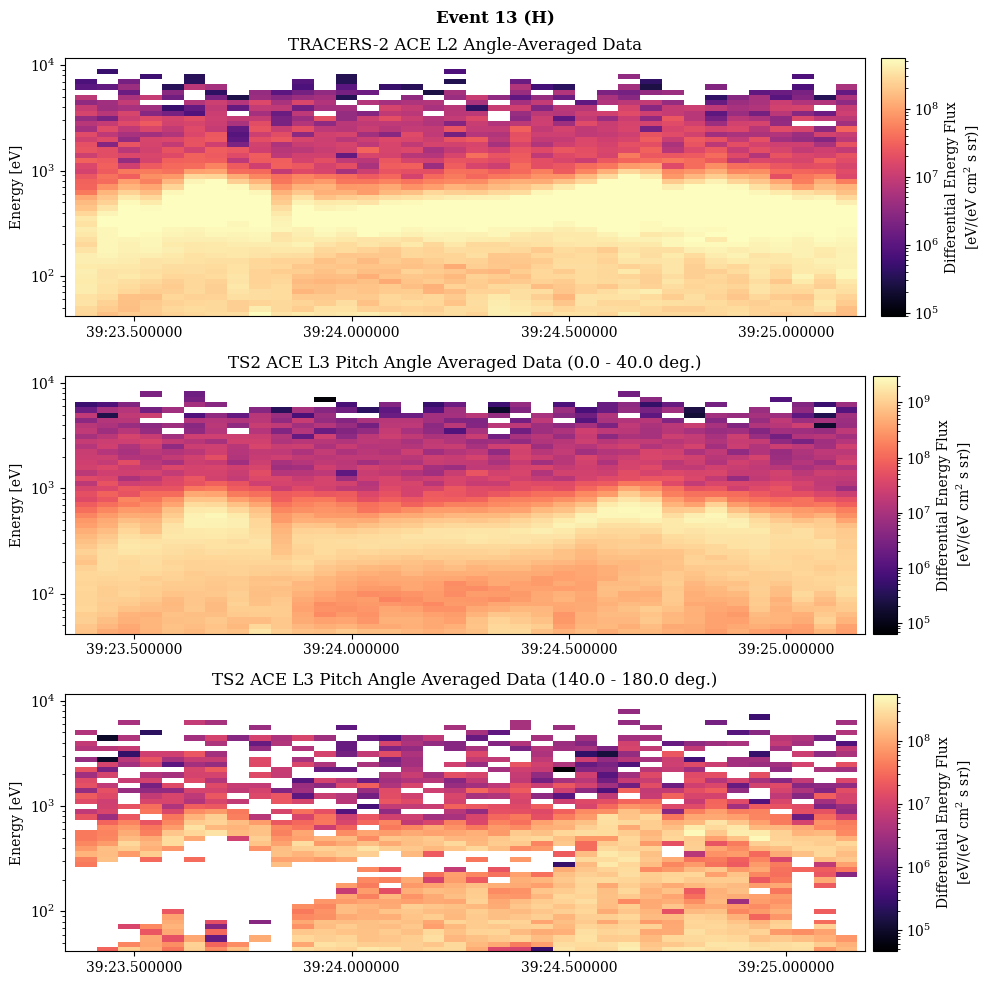

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


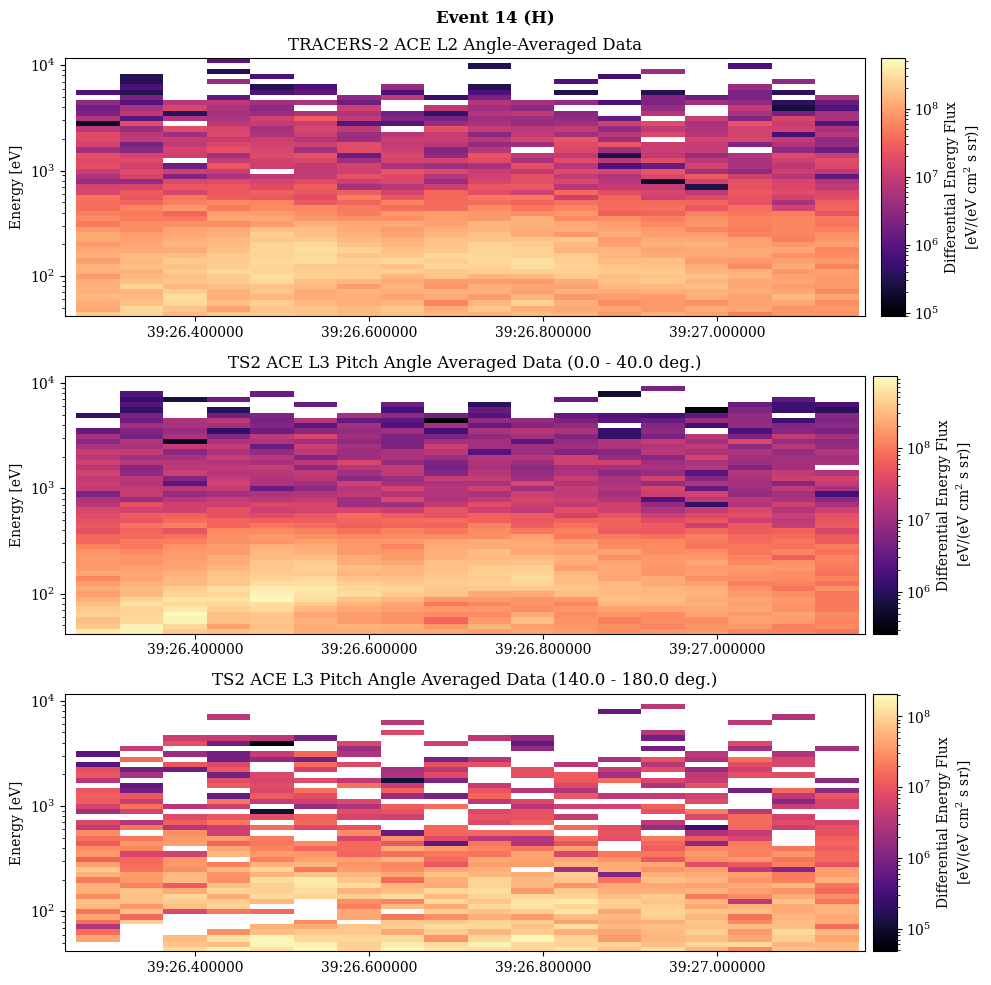

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


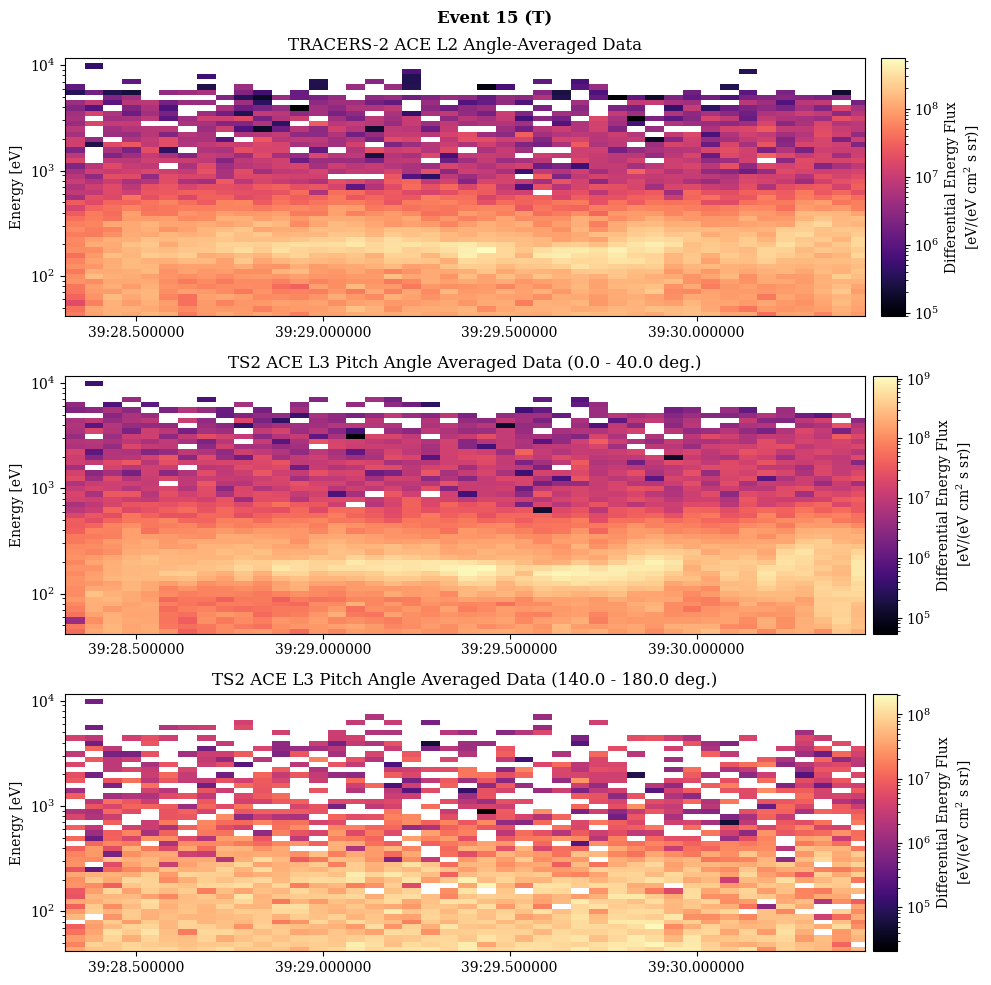

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


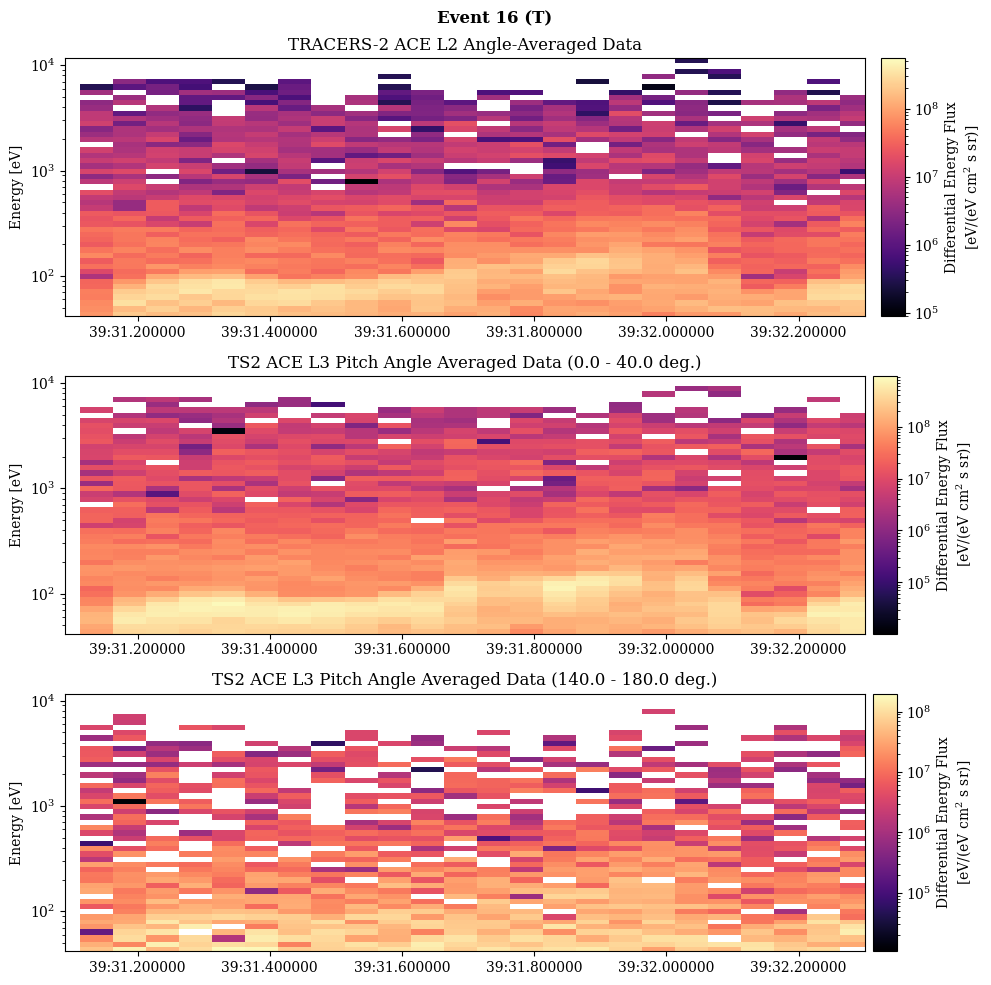

In [59]:
event_labels= ['T','T','T','H','T','H','H','T','H','H','H','H','H','H','T','T']
for k in range(len(cuspVs['Event'])):
    t0 = '2025-10-07/'+cuspVs['Start'].iloc[k]
    tf = '2025-10-07/'+cuspVs['End'].iloc[k]
    
    al2 = ACE_L2(t0,tf,'2')
    al2d = al2.read_data()

    al3 = ACE_L3(t0,tf,'2')
    al3d = al3.read_data()


    fig = plt.figure(figsize=(10,10))
    ax1 = fig.add_subplot(311)
    ax2 = fig.add_subplot(312)
    ax3 = fig.add_subplot(313)
    
    ax1 = plot_ace_l2(al2d,ax=ax1,cmap='magma',zlim=[1e5,5e8],title='TRACERS-2 ACE L2 Angle-Averaged Data')
    ylim = ax1.get_ylim()

    ax2 = plot_ace_l3(al3d,ax=ax2,cmap='magma',pa_bins2avg=[0,1,2,3])
    
    ax3 = plot_ace_l3(al3d,ax=ax3,cmap='magma',pa_bins2avg=[14,15,16,17])
    
    str2p = f'Event {k+1} ({event_labels[k]})'
    plt.suptitle(str2p,fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'ts2_event_{k+1}.png')
    plt.show()
    plt.close()

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


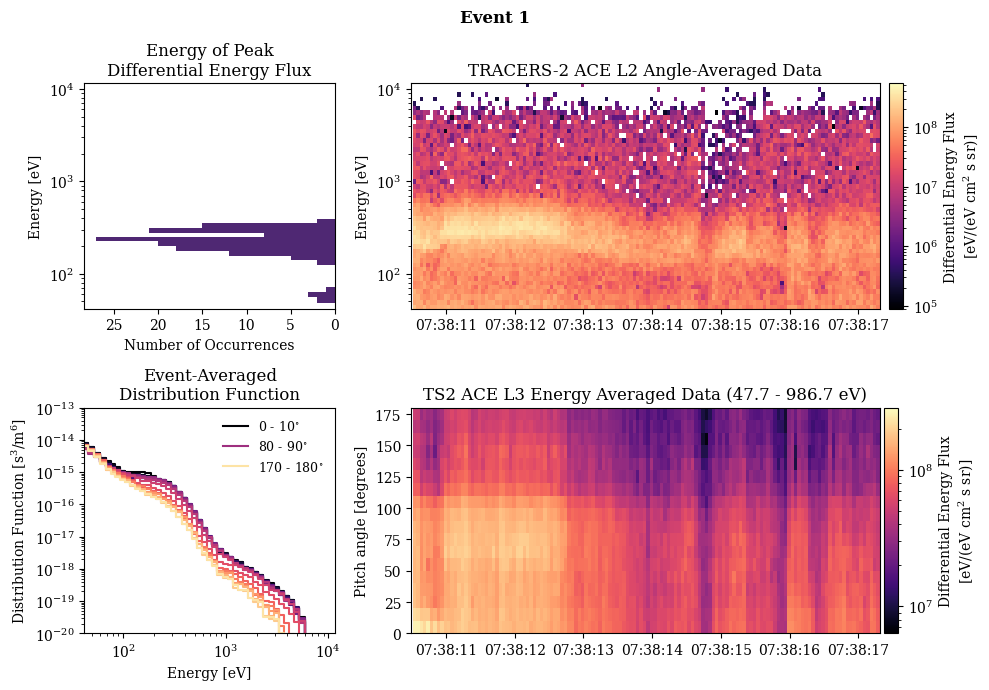

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


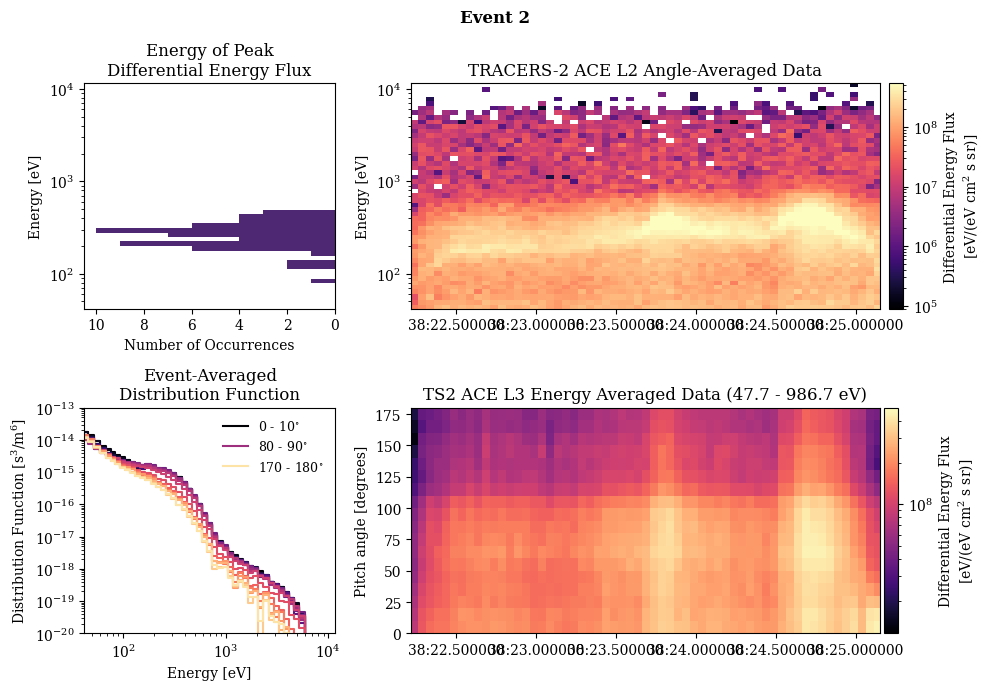

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


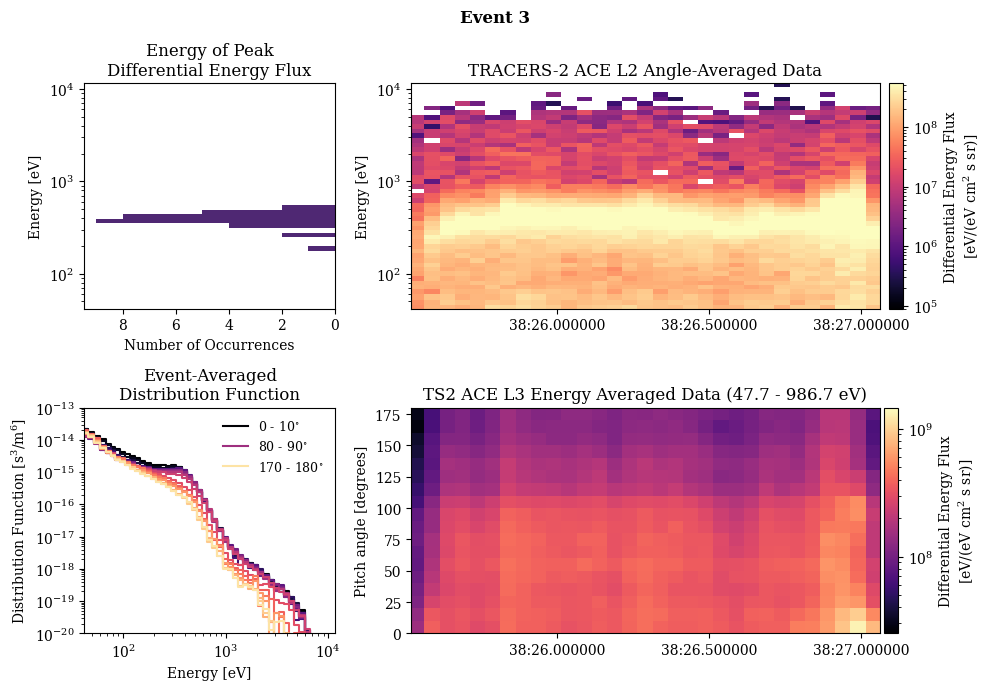

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


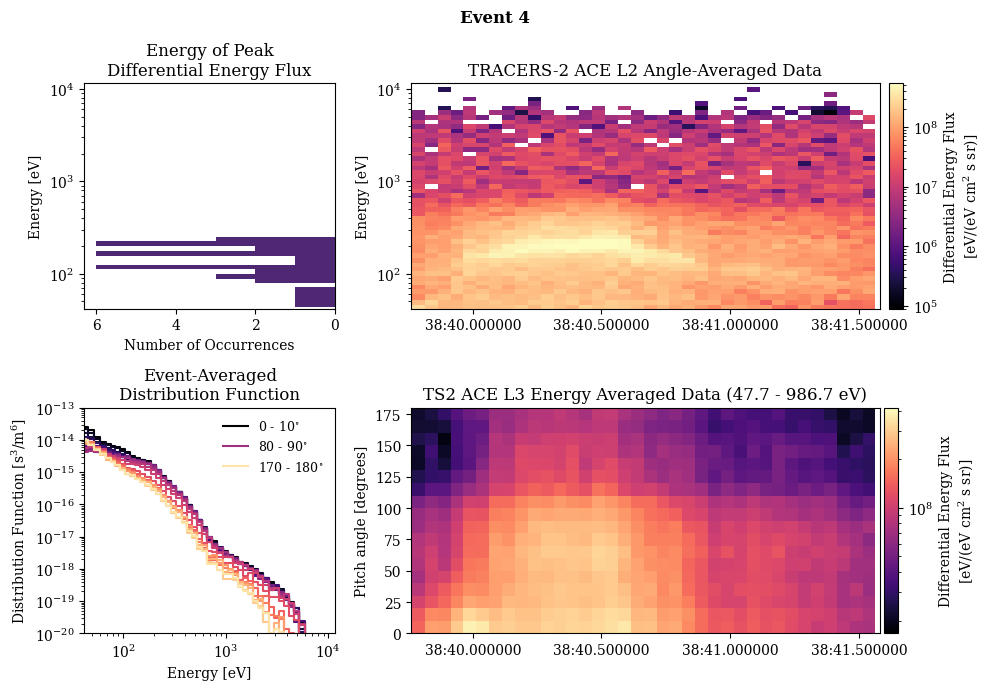

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


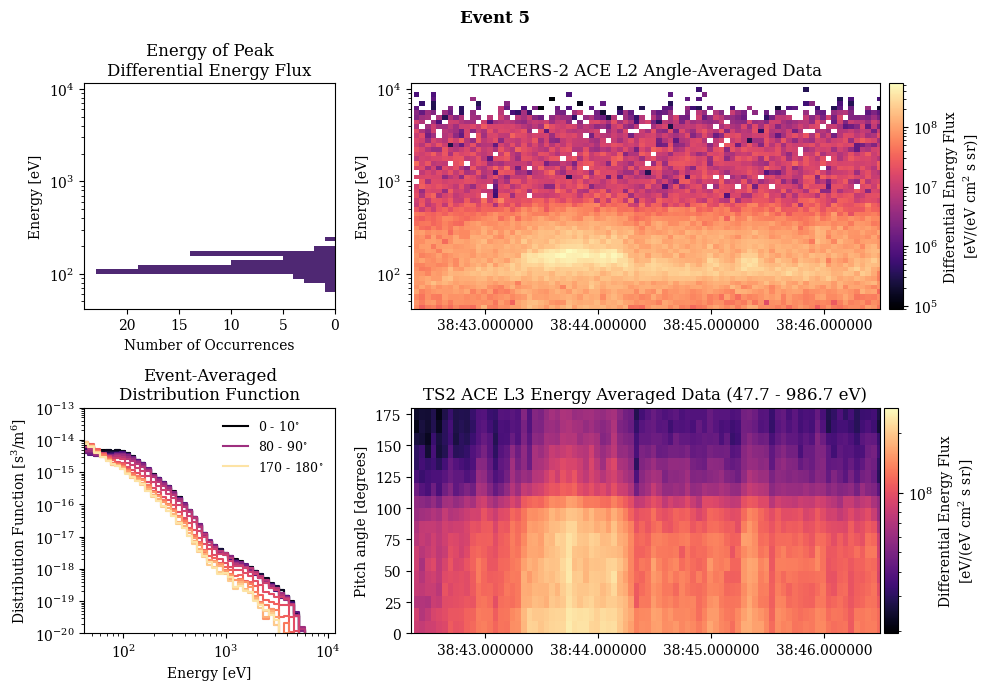

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


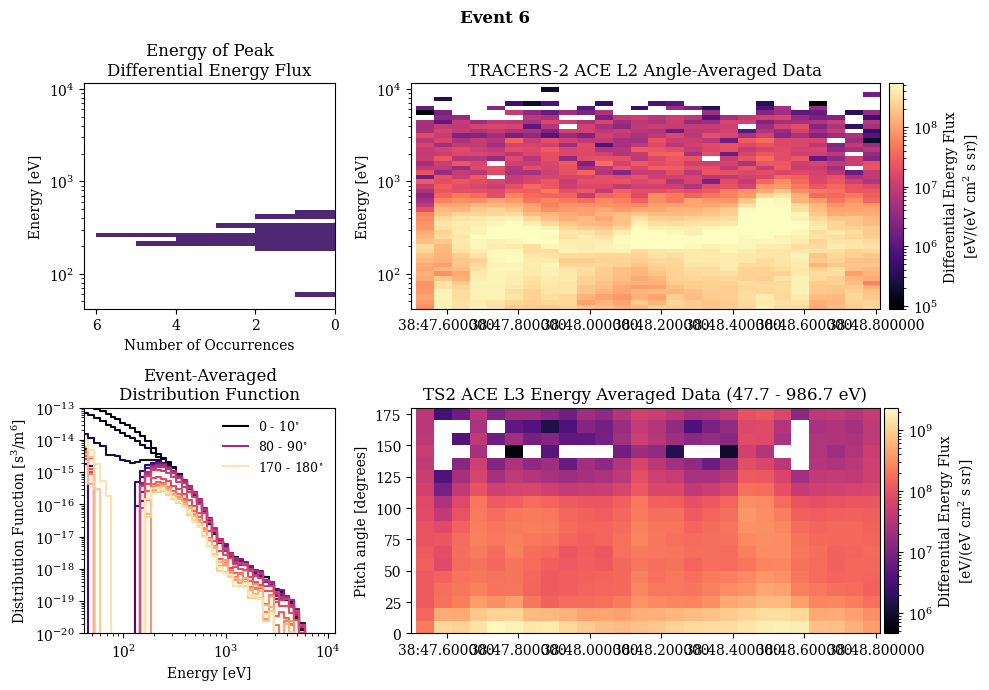

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


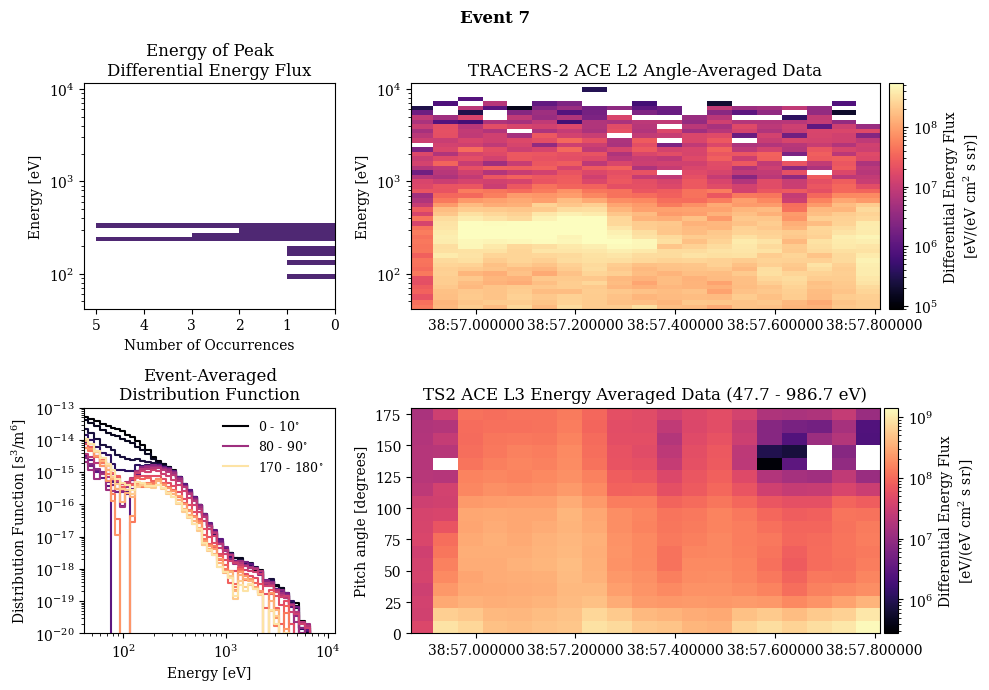

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


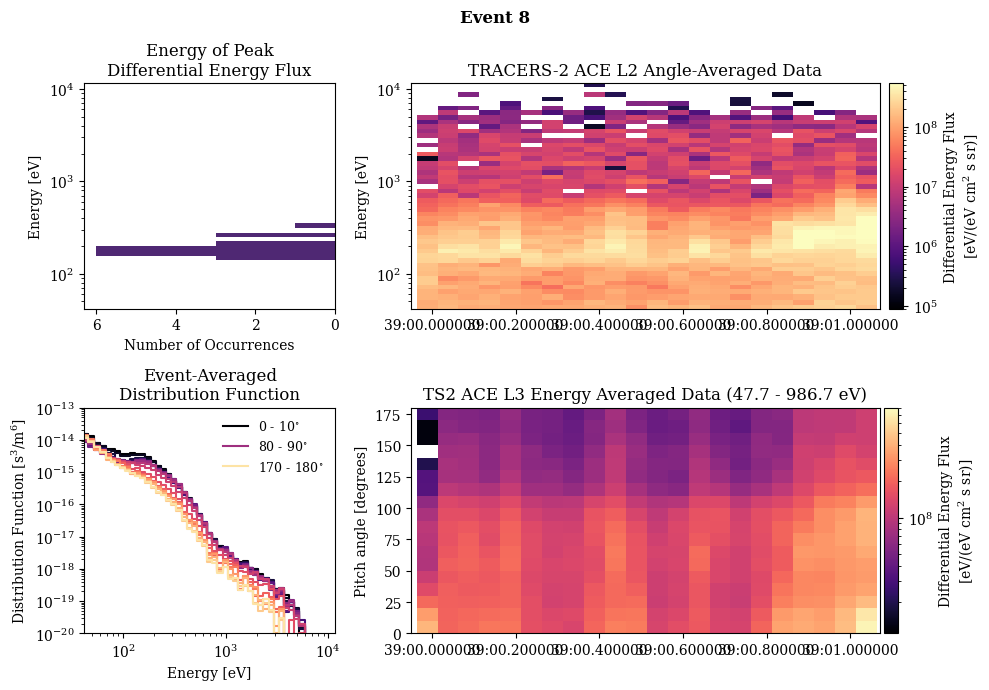

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


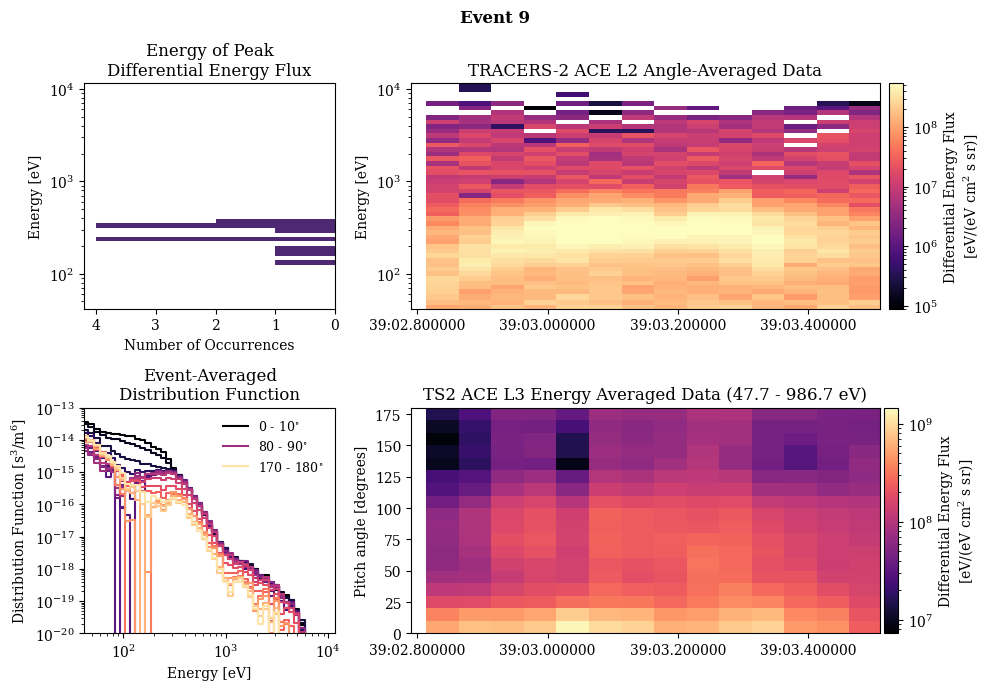

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


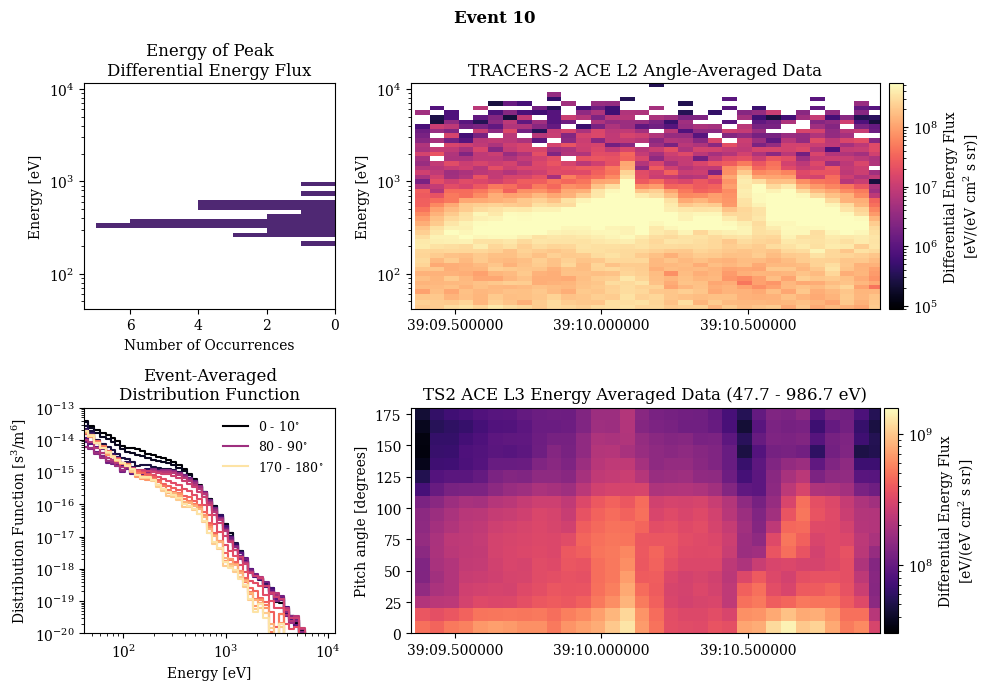

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


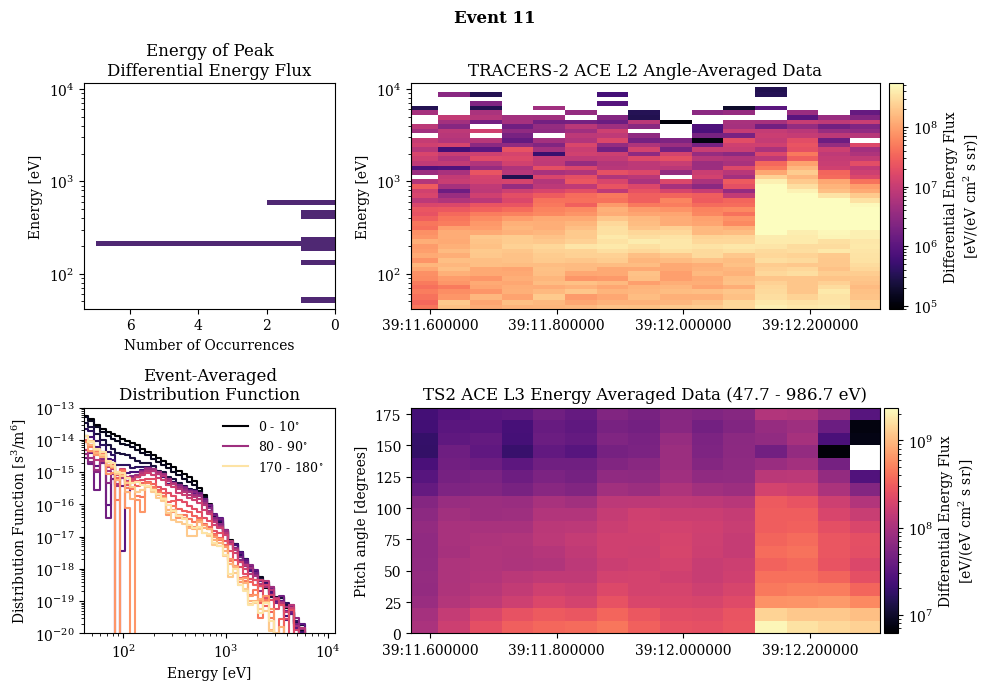

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


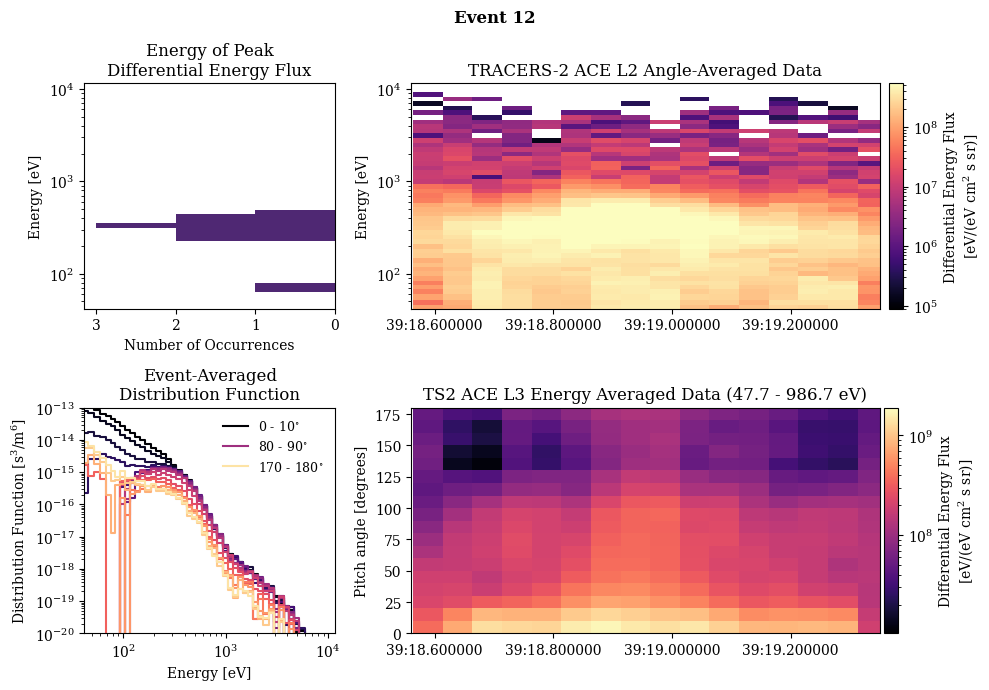

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


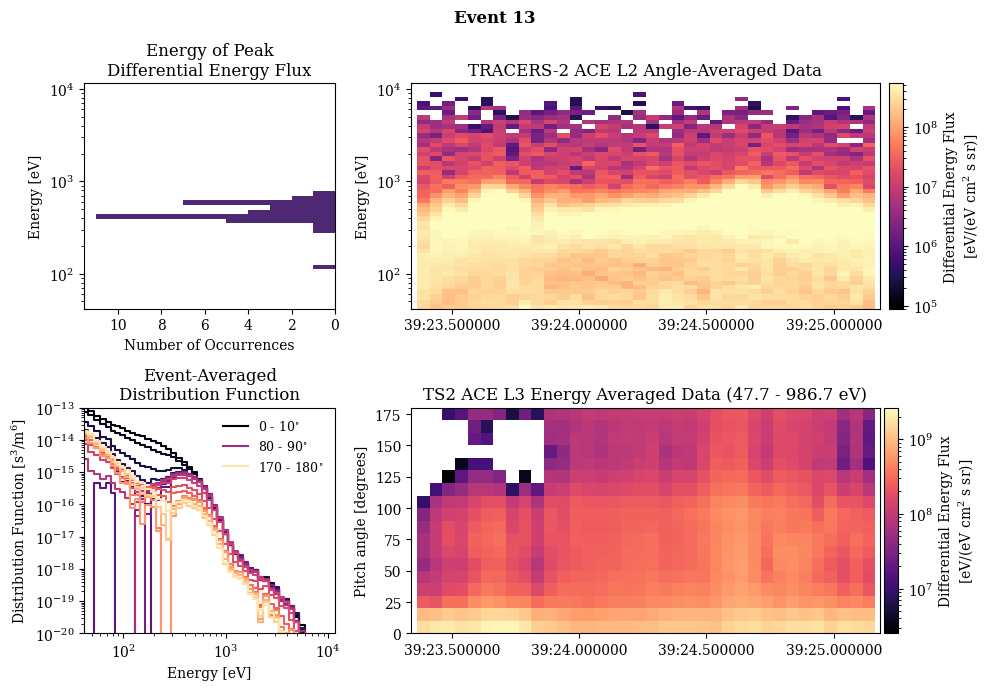

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


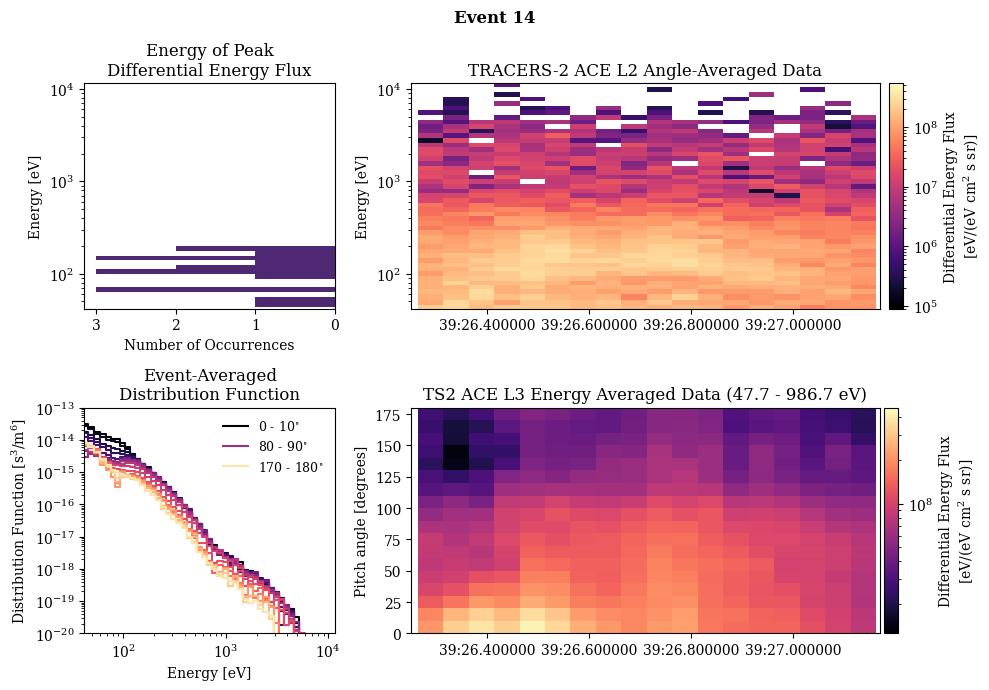

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


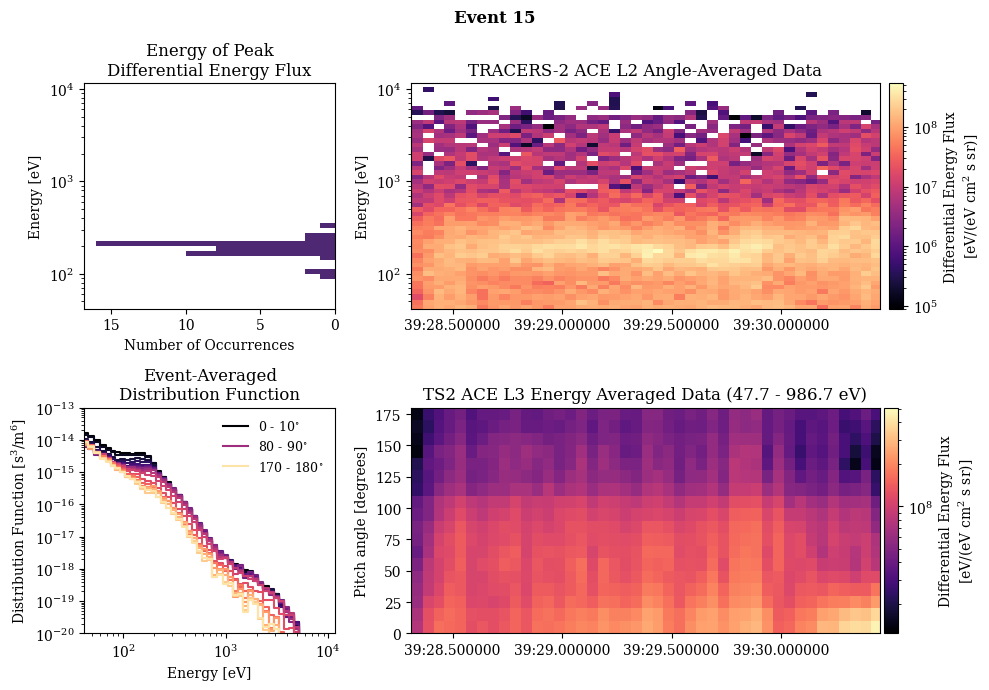

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


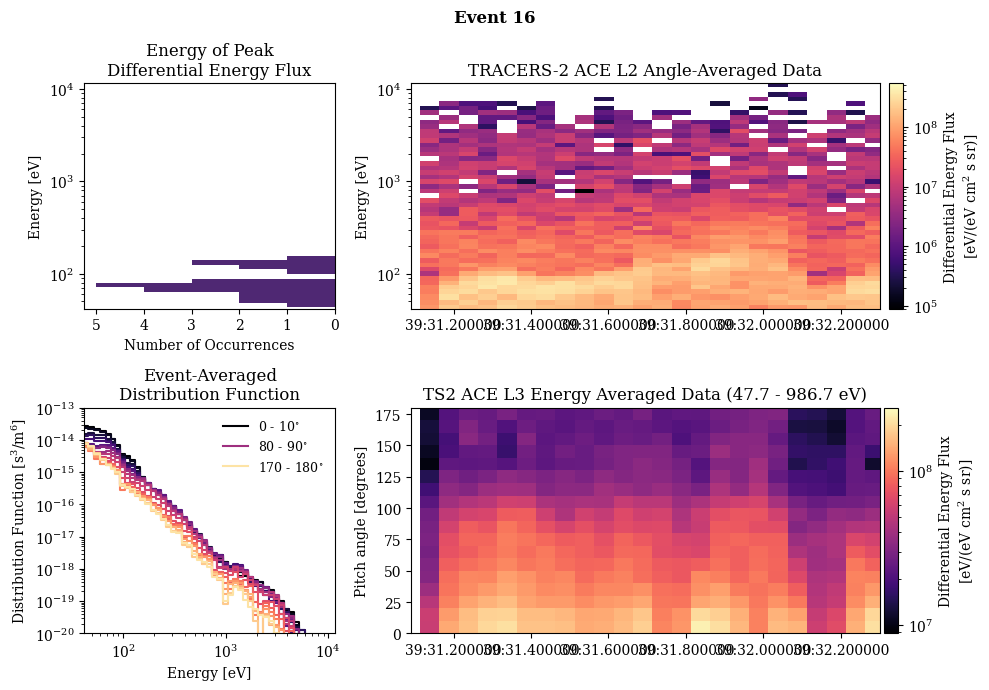

In [18]:
event_peak_energies = []
event_mean_energies = np.zeros(len(cuspVs['Event']))
event_std_energies = np.zeros(len(cuspVs['Event']))

for k in range(len(cuspVs['Event'])):
#for k in range(1):
    t0 = '2025-10-07/'+cuspVs['Start'].iloc[k]
    tf = '2025-10-07/'+cuspVs['End'].iloc[k]
    
    al2 = ACE_L2(t0,tf,'2')
    al2d = al2.read_data()

    al3 = ACE_L3(t0,tf,'2')
    al3d = al3.read_data()

    datetimes = np.array(al3d['DT'])
    flux = al2d['def']
    ang_avg = np.nanmean(flux,axis=2)
    peak_energies = np.zeros(len(datetimes))
    for t in range(len(datetimes)):
        ii = np.argmax(ang_avg[t,:])
        peak_energies[t] = al2d['energy'][ii]

    event_mean_energies[k] = np.nanmean(peak_energies)
    event_std_energies[k] = np.nanstd(peak_energies)
    
    event_peak_energies.append(peak_energies)    
    mass = 5.68566e-16 # eV/(cm2/s2)
    e_matrix = np.zeros((49,18))
    for i in range(18):
        e_matrix[:,i] = al3d['energy']
    df_conversion = 0.5*mass**2/(e_matrix**2) # [eV2/(cm2/s2)]/eV2
    distribution_function = al3d['def']*df_conversion*(100**6) # s3/m6

    fig = plt.figure(figsize=(10,7))
    gd = GridSpec(nrows=2,ncols=8)
    ax1 = fig.add_subplot(gd[0,3:8])
    ax1p = fig.add_subplot(gd[0,0:3])
    
    ax1 = plot_ace_l2(al2d,ax=ax1,cmap='magma',zlim=[1e5,5e8],title='TRACERS-2 ACE L2 Angle-Averaged Data')
    ylim = ax1.get_ylim()
    
    ax1p.hist(peak_energies, orientation='horizontal',bins=al2d['energy'][::-1],color='#4F2873')
    ax1p.set_xlim(ax1p.get_xlim()[::-1])
    ax1p.set_yscale('log')
    ax1p.set_ylim([ylim[0],ylim[1]])
    ax1p.set_ylabel('Energy [eV]')
    ax1p.set_xlabel('Number of Occurrences')
    ax1p.set_title('Energy of Peak\nDifferential Energy Flux')
    
    ax2 = fig.add_subplot(gd[1,0:3])
    cmap = plt.get_cmap('magma')
    for pa in range(18):
        pitch_angle_slice = distribution_function[:,:,pa]
        pitch_angle_avg = np.nanmean(pitch_angle_slice,axis=0)
        if pa == 0 or pa == 8 or pa == 17:
            ax2.step(al3d['energy'], pitch_angle_avg, where='mid', c=cmap(pa/18), label=f'{pa*10} - {(pa+1)*10}'+r'$^{\circ}$')
        else:
            ax2.step(al3d['energy'], pitch_angle_avg, where='mid', c=cmap(pa/18))
    ax2.set_xlim([ylim[0],ylim[1]])
    ax2.set_ylim([1e-20,1e-13])
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.legend(loc='upper right',frameon=False,fontsize=9)
    ax2.set_xlabel('Energy [eV]')
    ax2.set_ylabel(r'Distribution Function [s$^3$/m$^6$]')
    ax2.set_title('Event-Averaged\nDistribution Function')

    
    ax3 = fig.add_subplot(gd[1,3:8])
    ax3 = plot_ace_l3(al3d,ax=ax3,cmap='magma',energy_bins2avg=np.arange(21,48))
    
    str2p = f'Event {k+1}'
    plt.suptitle(str2p,fontweight='bold')
    plt.tight_layout()
    plt.show()




In [8]:
event_energies = [x for xs in event_peak_energies for x in xs]

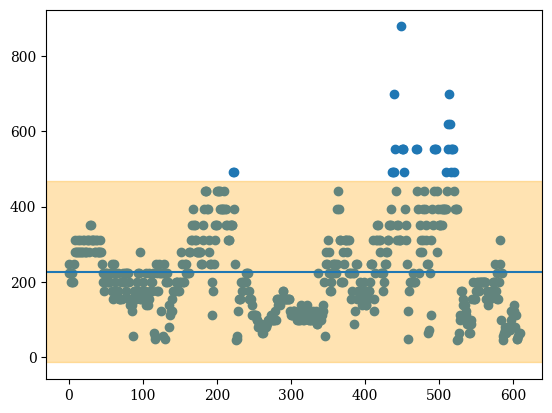

In [11]:
plt.scatter(np.arange(len(event_energies)), event_energies)
plt.axhline(np.mean(event_energies))
plt.axhspan(np.mean(event_energies)-2*np.std(event_energies), np.mean(event_energies)+2*np.std(event_energies),color='orange',alpha=0.3)
plt.show()

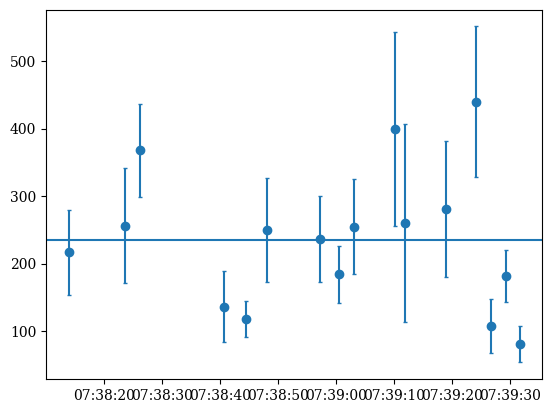

In [20]:
plt.errorbar(mid_times, event_mean_energies, yerr=event_std_energies, marker='o',ls='none',capsize=1.5)
plt.axhline(np.mean(event_mean_energies))

plt.show()

In [57]:
print(np.mean(event_mean_energies))
print(np.std(event_mean_energies))

235.62989984970088
99.88880566225792


In [46]:
event_mean_energies

array([216.58059429, 256.12599182, 367.97363527, 136.27345679,
       118.11724509, 249.5923748 , 237.05194413, 183.92847928,
       254.64237159, 398.87340784, 260.21267573, 280.75316501,
       440.09806209, 107.64829614, 181.63626045,  80.57043727])

In [59]:
trad = np.where(event_categories == 0)[0]
traditional_energies = event_mean_energies[trad]
traditional_lambda = [delta_lambda[x] for x in trad]
print(np.mean(traditional_energies))
print(np.std(traditional_energies))
print(np.mean(traditional_lambda))
print(np.std(traditional_lambda))

200.70466335399956
87.17833616243642
0.11097462142857142
0.06657072145214944


In [60]:
hybrid = np.where(event_categories != 0)[0]
hybrid_energies = event_mean_energies[hybrid]
hybrid_lambda = [delta_lambda[x] for x in hybrid]
print(np.mean(hybrid_energies))
print(np.std(hybrid_energies))
print(np.mean(hybrid_lambda))
print(np.std(hybrid_lambda))

262.79397267969074
100.70007899664796
0.05056100888888889
0.018316510110765245


In [ ]:
# Got this code from a crafty coder on google. These functions allow you to create your own color bar
# using input color hex values.
def hex_to_rgb(value):
    '''
    Converts hex to rgb colours
    value: string of 6 characters representing a hex colour.
    Returns: list length 3 of RGB values'''
    value = value.strip("#") # removes hash symbol if present
    lv = len(value)
    return tuple(int(value[i:i + lv // 3], 16) for i in range(0, lv, lv // 3))


def rgb_to_dec(value):
    '''
    Converts rgb to decimal colours (i.e. divides each value by 256)
    value: list (length 3) of RGB values
    Returns: list (length 3) of decimal values'''
    return [v/256 for v in value]
    
def get_continuous_cmap(hex_list, float_list=None):
    ''' creates and returns a color map that can be used in heat map figures.
        If float_list is not provided, colour map graduates linearly between each color in hex_list.
        If float_list is provided, each color in hex_list is mapped to the respective location in float_list. 
        
        Parameters
        ----------
        hex_list: list of hex code strings
        float_list: list of floats between 0 and 1, same length as hex_list. Must start with 0 and end with 1.
        
        Returns
        ----------
        colour map'''
    rgb_list = [rgb_to_dec(hex_to_rgb(i)) for i in hex_list]
    if float_list:
        pass
    else:
        float_list = list(np.linspace(0,1,len(rgb_list)))
        
    cdict = dict()
    for num, col in enumerate(['red', 'green', 'blue']):
        col_list = [[float_list[i], rgb_list[i][num], rgb_list[i][num]] for i in range(len(float_list))]
        cdict[col] = col_list
    cmp = LinearSegmentedColormap('my_cmp', segmentdata=cdict, N=256)
    return cmp


In [ ]:
hex_list = ['#D7BEEB','#BEDFEB','#D8F5D7','#FAE478','#E3A45B','#B81B07','#731003']

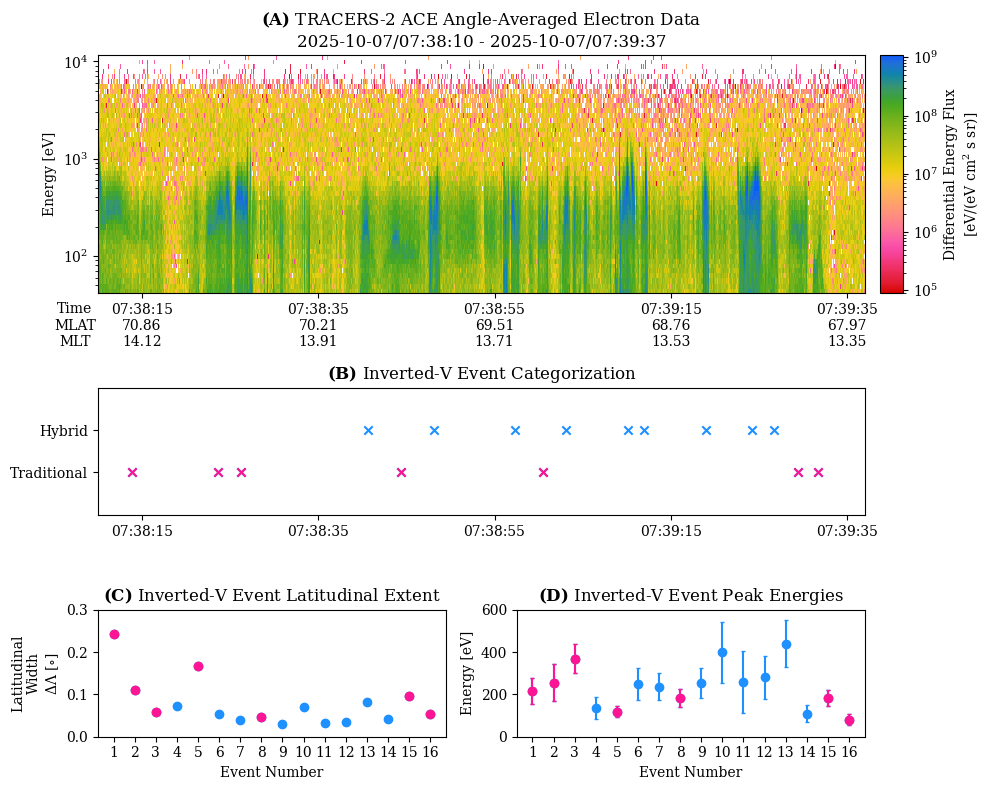

In [45]:
fig = plt.figure(figsize=(10,8))
gd = GridSpec(nrows=7,ncols=2)
ax1 = fig.add_subplot(gd[0:3,:])
t0 = '2025-10-07/07:38:10'
tf = '2025-10-07/07:39:37'
ax1 = plot_ace_l2(l2_data,ax=ax1,zlim=[1e5,1e9],title=r'$\mathbf{(A)}$'+' TRACERS-2 ACE Angle-Averaged Electron Data\n'+f'{t0} - {tf}')

tick_start = dt.datetime.strftime(l2_data['DT'][0] + dt.timedelta(seconds=5),'%Y-%m-%d/%H:%M:%S')
tick_end = dt.datetime.strftime(l2_data['DT'][-1],'%Y-%m-%d/%H:%M:%S')
new_tick_locations = pd.to_datetime(pd.date_range(start=tick_start,end=tick_end,freq='20s'))
new_ticks_utc = [(x - dt.datetime(1970,1,1)).total_seconds() for x in new_tick_locations]

mlt_interp_f = interp1d(ead_data['UTC'], ead_data['ts2_ead_mlt'], kind='linear')
mlat_interp_f = interp1d(ead_data['UTC'], ead_data['ts2_ead_mlat'], kind='linear')
interp_mlt = mlt_interp_f(new_ticks_utc)
interp_mlat = mlat_interp_f(new_ticks_utc)
ax1.set_xticks(new_tick_locations)

mlt0 = mlt_interp_f(new_ticks_utc)
mlat0 = mlat_interp_f(new_ticks_utc)

c0_ticks = []
c0_times = []
for k in range(len(mlt0)):
    tick_string = dt.datetime.strftime(new_tick_locations[k],'%H:%M:%S')
    mlt0_str = f'{mlt0[k]:.2f}'
    mlat0_str = f'{mlat0[k]:.2f}'
    c0_ticks.append(tick_string + '\n' + mlat0_str + '\n' + mlt0_str)
    c0_times.append(tick_string)
ax1.set_xticklabels(c0_ticks)
ax1.set_xlabel('Time\nMLAT\nMLT')
ax1.xaxis.set_label_coords(-0.03,-0.04)    

xlim = ax1.get_xlim()

binary_cmap = ListedColormap(['#D81B60', '#1E88E5'])
bounds = [0, 1.5, 3]

# 3. Create a normalization object that maps data values to the colors in the colormap
norm = BoundaryNorm(bounds, binary_cmap.N)

ax2 = fig.add_subplot(gd[3:5,:])
trad = np.where(event_categories == 0)[0]
tt = [mid_times[x] for x in trad]
ax2.scatter(mid_times, event_categories, marker='x', c='dodgerblue')
ax2.scatter(tt,event_categories[trad], marker='x', c='deeppink')
ax2.set_title(r'$\mathbf{(B)}$'+' Inverted-V Event Categorization')
ax2.set_ylim([-1,2])
ax2.set_xticks(new_tick_locations)
ax2.set_xticklabels(c0_times)
ax2.set_yticks([0,1])
ax2.set_yticklabels(['Traditional','Hybrid'])
ax2.set_xlim([xlim[0], xlim[1]])

xx = np.arange(1,17)
xf = xx[trad]
dl = [delta_lambda[x] for x in trad]
ax3 = fig.add_subplot(gd[5:,0])
ax3.set_ylabel('Latitudinal\nWidth\n'+r'$\Delta \Lambda \ [\circ]$')
ax3.set_ylim([0,0.3])
ax3.scatter(np.arange(1,17), delta_lambda,c='dodgerblue')
ax3.scatter(xf, dl,c='deeppink')
ax3.set_xticks(np.arange(1,17))
ax3.set_title(r'$\mathbf{(C)}$' + ' Inverted-V Event Latitudinal Extent')
ax3.set_xlabel('Event Number')


ax4 = fig.add_subplot(gd[5:,1])
ax4.errorbar(np.arange(1,17), event_mean_energies, yerr=event_std_energies, c='dodgerblue', ecolor='dodgerblue',marker='o', ls='none',capsize=1.5)
ax4.errorbar(xf, event_mean_energies[trad], yerr=event_std_energies[trad], c='deeppink', ecolor='deeppink',marker='o', ls='none',capsize=1.5)
ax4.set_ylabel('Energy [eV]')
ax4.set_title(r'$\mathbf{(D)}$' + ' Inverted-V Event Peak Energies')
ax4.set_xlabel('Event Number')
ax4.set_xticks(np.arange(1,17))
ax4.set_ylim([0,600])
plt.tight_layout()
plt.savefig('cusp_invertedV_event_behaviors.png',dpi=300)
plt.show()
plt.close()

In [42]:
t0 = '2025-10-07/'+cuspVs['Start'].iloc[0]
tf = '2025-10-07/'+cuspVs['End'].iloc[0]

al2 = ACE_L2(t0,tf,'2')
al2d = al2.read_data()

al3 = ACE_L3(t0,tf,'2')
al3d = al3.read_data()

datetimes = np.array(al3d['DT'])

peak_energies = np.zeros(len(datetimes))
for t in range(len(datetimes)):
    ii = np.argmax(ang_avg[t,:])
    peak_energies[t] = al2d['energy'][ii]


mass = 5.68566e-16 # eV/(cm2/s2)
e_matrix = np.zeros((49,18))
for i in range(18):
    e_matrix[:,i] = al3d['energy']
df_conversion = 0.5*mass**2/(e_matrix**2) # [eV2/(cm2/s2)]/eV2
distribution_function = al3d['def']*df_conversion*(100**6) # s3/m6

    

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf


Test
(136, 20, 18)
(136, 18)


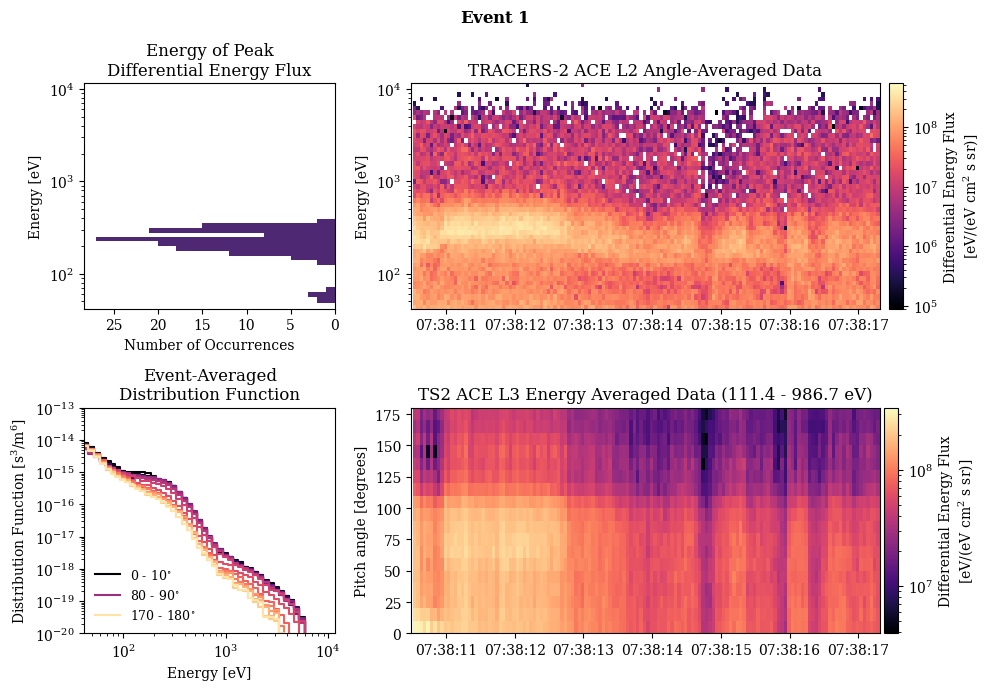

In [53]:
fig = plt.figure(figsize=(10,7))
gd = GridSpec(nrows=2,ncols=8)
ax1 = fig.add_subplot(gd[0,3:8])
ax1p = fig.add_subplot(gd[0,0:3])

ax1 = plot_ace_l2(al2d,ax=ax1,cmap='magma',zlim=[1e5,5e8],title='TRACERS-2 ACE L2 Angle-Averaged Data')
ylim = ax1.get_ylim()

ax1p.hist(peak_energies, orientation='horizontal',bins=al2d['energy'][::-1],color='#4F2873')
ax1p.set_xlim(ax1p.get_xlim()[::-1])
ax1p.set_yscale('log')
ax1p.set_ylim([ylim[0],ylim[1]])
ax1p.set_ylabel('Energy [eV]')
ax1p.set_xlabel('Number of Occurrences')
ax1p.set_title('Energy of Peak\nDifferential Energy Flux')

ax2 = fig.add_subplot(gd[1,0:3])
cmap = plt.get_cmap('magma')
for pa in range(18):
    pitch_angle_slice = distribution_function[:,:,pa]
    pitch_angle_avg = np.nanmean(pitch_angle_slice,axis=0)
    if pa == 0 or pa == 8 or pa == 17:
        ax2.step(al3d['energy'], pitch_angle_avg, where='mid', c=cmap(pa/18), label=f'{pa*10} - {(pa+1)*10}'+r'$^{\circ}$')
    else:
        ax2.step(al3d['energy'], pitch_angle_avg, where='mid', c=cmap(pa/18))
ax2.set_xlim([ylim[0],ylim[1]])
ax2.set_ylim([1e-20,1e-13])
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend(loc='lower left',frameon=False,fontsize=9)
ax2.set_xlabel('Energy [eV]')
ax2.set_ylabel(r'Distribution Function [s$^3$/m$^6$]')
ax2.set_title('Event-Averaged\nDistribution Function')



ax3 = fig.add_subplot(gd[1,3:8])
ax3 = plot_ace_l3(al3d,ax=ax3,cmap='magma',energy_bins2avg=np.arange(21,41))


plt.suptitle(r'$\mathbf{Event \ 1}$')
plt.tight_layout()
plt.show()

C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l2/2025/10/ts2_l2_ace_def_20251007_v1.0.0.cdf
C:\Users\shndrsn\TRACERS_data_routines/data/TS2/ACE/l3/2025/10/ts2_l3_ace_pitch-angle-dist_20251007_v1.0.0.cdf
Test
(136, 21, 18)
(136, 18)


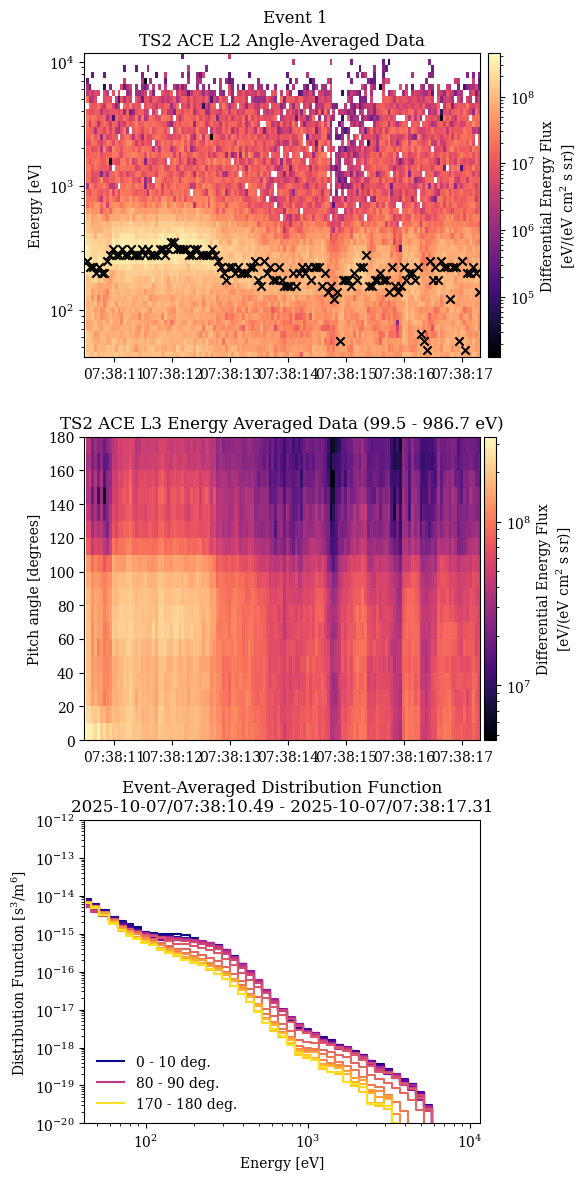

In [9]:
cmap = plt.get_cmap('plasma')
#for k in range(len(cuspVs['Event'])):
for k in range(1):
    t0 = '2025-10-07/'+cuspVs['Start'].iloc[k]
    tf = '2025-10-07/'+cuspVs['End'].iloc[k]
    
    al2 = ACE_L2(t0,tf,'2')
    al2d = al2.read_data()

    al3 = ACE_L3(t0,tf,'2')
    al3d = al3.read_data()

    datetimes = np.array(al3d['DT'])

    mass = 5.68566e-16 # eV/(cm2/s2)
    e_matrix = np.zeros((49,18))
    for i in range(18):
        e_matrix[:,i] = al3d['energy']
    df_conversion = 0.5*mass**2/(e_matrix**2) # [eV2/(cm2/s2)]/eV2
    distribution_function = al3d['def']*df_conversion*(100**6) # s3/m6

    
    fig, ax = plt.subplots(ncols=1,nrows=3,figsize=(6,12))

    # ++++++++++++++++++++++++++++++++++++++++++++++
    ax[0] = plot_ace_l2(al2d, ax=ax[0],time_res='1s',cmap='magma')
    ylim = ax[0].get_ylim()
    
    flux = al2d['def']
    ang_avg = np.nanmean(flux,axis=2)
   
    for t in range(len(datetimes)):
        ii = np.argmax(ang_avg[t,:])
        peak_energy = al2d['energy'][ii]
        ax[0].scatter(datetimes[t], peak_energy, marker='x', c='k')

    # ++++++++++++++++++++++++++++++++++++++++++++++
    ax[1] = plot_ace_l3(al3d,ax=ax[1],cmap='magma',energy_bins2avg=np.arange(21,42))
    # ++++++++++++++++++++++++++++++++++++++++++++++

    for pa in range(18):
        pitch_angle_slice = distribution_function[:,:,pa]
        pitch_angle_avg = np.nanmean(pitch_angle_slice,axis=0)
        if pa == 0 or pa == 8 or pa == 17:
            ax[2].step(al3d['energy'], pitch_angle_avg, where='mid', c=cmap(pa/18), label=f'{pa*10} - {(pa+1)*10} deg.')
        else:
            ax[2].step(al3d['energy'], pitch_angle_avg, where='mid', c=cmap(pa/18))
    ax[2].set_xlim([ylim[0],ylim[1]])
    ax[2].set_ylim([1e-20,1e-12])
    ax[2].set_xscale('log')
    ax[2].set_yscale('log')
    ax[2].legend(loc='lower left',frameon=False)
    ax[2].set_xlabel('Energy [eV]')
    ax[2].set_ylabel(r'Distribution Function [s$^3$/m$^6$]')
    ax[2].set_title('Event-Averaged Distribution Function\n'+f'{t0} - {tf}')

    # ax[2] = plot_epad_snapshot(al3d,ax=ax[2],units='df',cmap='plasma')
    # ax[2].set_title('Event-Summed VDF')
    plt.suptitle(f'Event {k+1}')
    plt.tight_layout()
    plt.show()

In [ ]:
# This will load ephemeris & attitude data 
ead = EADload('2025-11-10/12:00','2025-11-10/13:00','2')
ead_data = ead.read_data()

In [ ]:
# This is how you load ACE L2 data using my libraries
ace_l2 = ACE_L2('2025-11-10/12:00','2025-11-10/13:00','2')
ace_l2_data = ace_l2.read_data()

# This is how you load ACe L3 data using my libraries
ace_l3 = ACE_L3('2025-11-10/12:00','2025-11-10/13:00','2')
ace_l3_data = ace_l3.read_data()

# This is how you load ACI L2 data using my libraries
aci_l2 = ACI_L2('2025-11-10/12:00','2025-11-10/13:00','2')
aci_l2_data = aci_l2.read_data()

In [ ]:
ax = plot_ace_l3(ace_l3_data,units='df')
plt.show()

In [ ]:
fig = plt.figure(figsize=(8,9))
ax1 = fig.add_subplot(311)
# This is the default plot generated for ACE L2. It's an energy-time series generated by averaging
# the signal over all of ACE's anodes.
ax1 = plot_ace_l2(ace_l2_data,ax=ax1,spice=True,time_res='10min')

ax2 = fig.add_subplot(312,sharex=ax1)
# Here is a nominal pitch angle plot. By default, it averages over all 
# energy bins to generate an average flux per pitch angle bin per time.
ax2 = plot_ace_l3(ace_l3_data,ax=ax2,spice=True,time_res='10min')

ax3 = fig.add_subplot(313,sharex=ax1)
# Here's the default ACI plot. Similar to ACE, it's go-to is an energy-time series generated
# by averaging over all of ACI's anodes.
ax3 = plot_aci_l2(aci_l2_data,ax=ax3,spice=True,time_res='10min')

plt.tight_layout()
plt.show()

In [ ]:
# Here I'm just showing what different key words can do for each plotting function.
# In the first plot, I entered an arbitrary title, changed the color map, and told
# the function to averge over all ACE energy channels.
# In the second plot, I told the function to average over the first four pitch angle bins and also 
# changed the color map.
# Lastly, I told the ACI data loader to plot counts and sum over all anodes.

fig = plt.figure(figsize=(8,9))
ax1 = fig.add_subplot(311)
ax1 = plot_ace_l2(ace_l2_data,ax=ax1,energy_avg=True,time_res='10min',\
                  cmap='viridis',title='Testing the title function')

ax2 = fig.add_subplot(312,sharex=ax1)
ax2 = plot_ace_l3(ace_l3_data,ax=ax2,pa_bins2avg=[0,1,2,3],time_res='10min',cmap='rainbow')

ax3 = fig.add_subplot(313,sharex=ax1)
ax3 = plot_aci_l2(aci_l2_data,ax=ax3,spice=True,time_res='10min',units='counts',cmap='plasma',anode_sum=True)

plt.tight_layout()
plt.show()